# Otimização de Agendas no SUS: Previsão de No-Shows

Este código realiza uma análise exploratória de dados (EDA) focada em entender os padrões de absenteísmo em consultas médicas na rede pública.

Vamos analisar uma base de dados reais da cidade de Vitória (ES) para explorar o comportamento de faltas com base em variáveis como:

- Idade do paciente (Age)
- Tempo de espera entre a marcação e a consulta (WaitingDays)
- Recebimento de lembretes (SMS_received)
- Condições preexistentes (Hipertensão, Diabetes, etc.)

Ao final desta etapa queremos entender o seguinte: “Quais características e comportamentos históricos mais influenciam a probabilidade de um paciente faltar à consulta?”

---
*Desenvolvido pela equipe para o projeto de Overbooking Inteligente.*

# Dataset

Foi utilizado um dataset disponível para download no Kaggle:
https://www.kaggle.com/datasets/joniarroba/noshowappointments

Este dataset, chamado de "Medical Appointment No Shows", consiste em 110.527 registros de consultas médicas da rede pública da cidade de Vitória (ES), Brasil. Os dados estão armazenados como linhas com as seguintes colunas originais:

- PatientId: identificador exclusivo do paciente.
- AppointmentID: identificador exclusivo do agendamento da consulta.
- Gender: sexo do paciente (F para feminino ou M para masculino).
- ScheduledDay: data e hora em que o paciente realizou a marcação da consulta.
- AppointmentDay: data para a qual a consulta médica foi agendada.
- Age: idade do paciente em anos.
- Neighbourhood: bairro de Vitória (ES) onde a unidade de saúde está localizada.
- Scholarship: indica se o paciente é beneficiário do programa social Bolsa Família (1 = Sim, 0 = Não).
- Hipertension, Diabetes, Alcoholism, Handcap: variáveis binárias (1 ou 0) que indicam se o paciente possui diagnóstico de hipertensão, diabetes, alcoolismo ou alguma deficiência.
- SMS_received: indica se o paciente recebeu uma ou mais mensagens de texto como lembrete da consulta (1 = Sim, 0 = Não).
- No-show: variável alvo que indica se o paciente faltou à consulta ("Yes" = Faltou; "No" = Compareceu).

*Nota: Durante a fase de Engenharia de Dados, criaremos também a variável "WaitingDays" (Dias de Espera), calculada a partir da diferença entre o ScheduledDay e o AppointmentDay.*

# Importar as Bibliotecas

Carrega bibliotecas que são ferramentas de trabalho para:

- Manipular dados (pandas, numpy)
- Fazer gráficos (matplotlib, seaborn)
- Construir modelos de IA

Bibliotecas específicas serão importadas ao longo do script.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual padrão para os gráficos
sns.set_theme(style="whitegrid")

# Coletar os Dados
Vamos fazer o download do dataset e armazená-lo em um DataFrame.

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/bkumar080/No-Show-Medical-Appointment-Investigation/master/noshowappointments-kagglev2-may-2016.csv"

df = pd.read_csv(url)

df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


#Análise Exploratória dos Dados (EDA) - 1a Parte
#### *Objetivos:*
- Entender os dados crus que foram recebidos;

- Detectar valores ausentes, duplicados ou inconsistências;

- Explorar a distribuição das variáveis (tendência, dispersão, outliers);

- Avaliar o balanceamento das classes no target;

- Verificar correlações iniciais entre variáveis;

- Identificar problemas de escala, unidades ou codificação de categorias;

Essa etapa mostra o que precisa ser corrigido e orienta quais transformações aplicar.

##Cabeçalho

In [ ]:
#Imprime as primeiras linhas
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


##Rodape

In [ ]:
#Imprime as últimas linhas
df.tail()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
110522,2.572134e+12,5651768,F,2016-05-03T09:15:35Z,2016-06-07T00:00:00Z,56,MARIA ORTIZ,0,0,0,0,0,1,No
110523,3.596266e+12,5650093,F,2016-05-03T07:27:33Z,2016-06-07T00:00:00Z,51,MARIA ORTIZ,0,0,0,0,0,1,No
110524,1.557663e+13,5630692,F,2016-04-27T16:03:52Z,2016-06-07T00:00:00Z,21,MARIA ORTIZ,0,0,0,0,0,1,No
110525,9.213493e+13,5630323,F,2016-04-27T15:09:23Z,2016-06-07T00:00:00Z,38,MARIA ORTIZ,0,0,0,0,0,1,No
110526,3.775115e+14,5629448,F,2016-04-27T13:30:56Z,2016-06-07T00:00:00Z,54,MARIA ORTIZ,0,0,0,0,0,1,No


##Tipos dos Dados

In [ ]:
# Este comando é mais completo que o dtypes, utilizado logo abaixo
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB
None


In [ ]:
# Este comando tem uma saída mais simples
print(df.dtypes)

PatientId         float64
AppointmentID       int64
Gender             object
ScheduledDay       object
AppointmentDay     object
Age                 int64
Neighbourhood      object
Scholarship         int64
Hipertension        int64
Diabetes            int64
Alcoholism          int64
Handcap             int64
SMS_received        int64
No-show            object
dtype: object


In [ ]:
# Descobrir os valores únicos contidos nas colunas
# Isso ajuda a entender melhor a estrutura dos dados e identificar colunas categóricas, numéricas, e erros (valores inesperados).

for col in df.columns:
    print(f"\nColuna: {col}")
    print(df[col].unique())


Coluna: PatientId
[2.98724998e+13 5.58997777e+14 4.26296230e+12 ... 7.26331493e+13
 9.96997666e+14 1.55766317e+13]

Coluna: AppointmentID
[5642903 5642503 5642549 ... 5630692 5630323 5629448]

Coluna: Gender
['F' 'M']

Coluna: ScheduledDay
['2016-04-29T18:38:08Z' '2016-04-29T16:08:27Z' '2016-04-29T16:19:04Z' ...
 '2016-04-27T16:03:52Z' '2016-04-27T15:09:23Z' '2016-04-27T13:30:56Z']

Coluna: AppointmentDay
['2016-04-29T00:00:00Z' '2016-05-03T00:00:00Z' '2016-05-10T00:00:00Z'
 '2016-05-17T00:00:00Z' '2016-05-24T00:00:00Z' '2016-05-31T00:00:00Z'
 '2016-05-02T00:00:00Z' '2016-05-30T00:00:00Z' '2016-05-16T00:00:00Z'
 '2016-05-04T00:00:00Z' '2016-05-19T00:00:00Z' '2016-05-12T00:00:00Z'
 '2016-05-06T00:00:00Z' '2016-05-20T00:00:00Z' '2016-05-05T00:00:00Z'
 '2016-05-13T00:00:00Z' '2016-05-09T00:00:00Z' '2016-05-25T00:00:00Z'
 '2016-05-11T00:00:00Z' '2016-05-18T00:00:00Z' '2016-05-14T00:00:00Z'
 '2016-06-02T00:00:00Z' '2016-06-03T00:00:00Z' '2016-06-06T00:00:00Z'
 '2016-06-07T00:00:00Z' '2016-

### Estatística Descritiva e Identificação de Outliers

A análise descritiva é a primeira etapa da análise de dados e tem como objetivo resumir, organizar e entender as principais características de um conjunto de dados de forma simples e objetiva, sem tirar conclusões causais ou fazer previsões.

Para aprofundar nossa compreensão estatística, calculamos o Intervalo Interquartil (IQR) e os limites matemáticos para identificar valores atípicos (*outliers*). Também desdobramos essa visualização por classes (quem faltou vs. quem compareceu) para observar diferenças de comportamento.

**Entendendo as métricas calculadas:**
* **Média e Mediana (50%):** Indicam a tendência central da distribuição.
* **Moda:** O valor que aparece com maior frequência no conjunto de dados.
* **Desvio Padrão:** Mede a dispersão, ou seja, o quanto os valores variam em relação à média.
* **Mínimo e Máximo:** Os limites absolutos encontrados na variável.
* **Q1 (25%) e Q3 (75%):** O primeiro e o terceiro quartis.
* **IQR (Intervalo Interquartil):** A diferença entre o Q3 e o Q1 ($IQR = Q3 - Q1$). Ele representa o intervalo onde se concentram os 50% dos dados centrais.
* **Qtd Outliers:** Contagem exata de registros que estão além do limite de normalidade estatística (abaixo de $Q1 - 1.5 \times IQR$ ou acima de $Q3 + 1.5 \times IQR$).

#### *Observações da Análise*
* **Idade (`Age`):** Os dados mostram que a idade média de quem falta (34 anos) é ligeiramente menor do que a de quem comparece (37 anos). A tabela revelou um valor mínimo de **-1**, o que indica um erro de digitação (ruído) que será tratado na etapa de Engenharia de Dados. Já os *outliers* superiores (idade máxima de 115 anos) representam a longevidade natural de alguns pacientes no sistema de saúde e serão mantidos.
* **Comorbidades Múltiplas (`Handcap`):** É importante documentar que a variável `Handcap` possui valores que vão de 0 a 4. Diferente das outras doenças que são binárias, esta é uma variável ordinal que contabiliza o *número de deficiências* simultâneas que o paciente possui. Logo, valores acima de 1 não são *outliers* ou erros.

In [ ]:
# Função para gerar estatística completa
def estatistica_detalhada(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    limite_superior = q3 + 1.5 * iqr
    limite_inferior = q1 - 1.5 * iqr
    outliers = series[(series < limite_inferior) | (series > limite_superior)].count()

    return pd.Series({
        'Média': round(series.mean(), 2),
        'Mediana': series.median(),
        'Moda': series.mode()[0] if not series.mode().empty else np.nan,
        'Desvio Padrão': round(series.std(), 2),
        'Mínimo': series.min(),
        'Q1 (25%)': q1,
        'Q3 (75%)': q3,
        'Máximo': series.max(),
        'IQR': iqr,
        'Qtd Outliers': outliers
    })

# Verifica de forma dinâmica quais colunas numéricas contínuas já existem neste momento do código
cols = [col for col in ['Age', 'DiasEspera'] if col in df.columns]

# Gerando a tabela para o Dataset Completo, Comparecimentos (No) e Faltas (Yes)
resumo_geral = df[cols].apply(estatistica_detalhada).T
resumo_geral['Filtro'] = '1. Geral'

resumo_no = df[df['No-show'] == 'No'][cols].apply(estatistica_detalhada).T
resumo_no['Filtro'] = '2. Compareceu (No)'

resumo_yes = df[df['No-show'] == 'Yes'][cols].apply(estatistica_detalhada).T
resumo_yes['Filtro'] = '3. Faltou (Yes)'

# Consolidando e organizando a exibição
tabela_final = pd.concat([resumo_geral, resumo_no, resumo_yes]).reset_index()
tabela_final = tabela_final.rename(columns={'index': 'Variável'})

# Reordenando colunas para melhor leitura
ordem = ['Variável', 'Filtro', 'Média', 'Mediana', 'Moda', 'Desvio Padrão', 'Mínimo', 'Q1 (25%)', 'Q3 (75%)', 'Máximo', 'IQR', 'Qtd Outliers']
display(tabela_final[ordem].sort_values(by=['Variável', 'Filtro']))

,Variável,Filtro,Média,Mediana,Moda,Desvio Padrão,Mínimo,Q1 (25%),Q3 (75%),Máximo,IQR,Qtd Outliers
0,Age,1. Geral,37.09,37.0,0.0,23.11,-1.0,18.0,55.0,115.0,37.0,5.0
1,Age,2. Compareceu (No),37.79,38.0,0.0,23.34,-1.0,18.0,56.0,115.0,38.0,2.0
2,Age,3. Faltou (Yes),34.32,33.0,0.0,21.97,0.0,16.0,51.0,115.0,35.0,3.0


## Status do Agendamento (Comparecimento x Falta)

Contagem da variável alvo para verificar a proporção de pacientes que compareceram ou faltaram à consulta.

In [ ]:
# Conta os valores da coluna No-show
status_consulta = df['No-show'].value_counts().reset_index()

# Renomeia as colunas
status_consulta.columns = ['Status (No-show)', 'Quantidade']

print(status_consulta)

  Status (No-show)  Quantidade
0               No       88208
1              Yes       22319


### Gráfico de Faltas x Comparecimento (Status)

Visualização da distribuição da variável alvo para entender o balanceamento dos dados. Nesta etapa, também aproveitamos para exportar uma cópia do dataset em formato Excel para eventuais consultas de negócio.

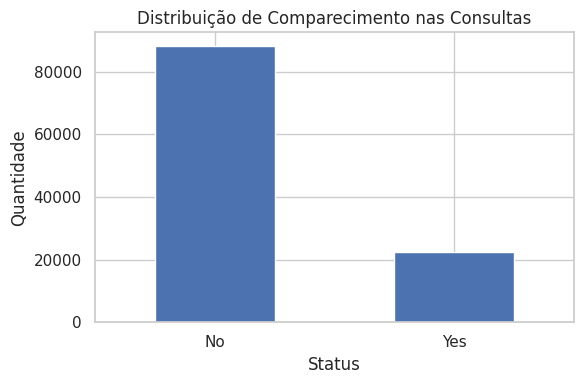

In [ ]:
# Exporta o dataset para Excel
df.to_excel("dataset_consultas_medicas.xlsx", index=False)

# Contagem da variável alvo
no_show_counts = df["No-show"].value_counts()

# Geração do gráfico
plt.figure(figsize=(6,4))
no_show_counts.plot(kind="bar")
plt.title("Distribuição de Comparecimento nas Consultas")
plt.xlabel("Status")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)

plt.tight_layout() # Mantém o ajuste de margens padrão do professor
plt.show()

#### *Análise*

> Os dados confirmam um dataset desbalanceado, com a classe `0` (Compareceu / No) concentrando a grande maioria dos exemplos (**88.208 registros, representando 79,8%**) e a classe `1` (Faltou / Yes) aparecendo em menor quantidade (**22.319 registros, representando 20,2%**). Embora não seja um desbalanceamento extremo como em sistemas de detecção de fraude, essa proporção já exige muito cuidado, uma vez que o nosso maior interesse de negócio é justamente identificar e prever a classe minoritária (os 20% que vão faltar) para agir preventivamente.

#### *Problemas de usar um dataset desbalanceado em IA*
- **Viés do modelo**: o algoritmo tende a prever sempre a classe majoritária (ex.: `Compareceu`), porque assim já alcança alta acurácia rapidamente, ignorando os sutis padrões da classe minoritária;
- **Baixa capacidade de generalização**: ele não aprende de fato a identificar os fatores que levam à falta, o que compromete a utilidade prática do modelo no dia a dia do hospital;
- **Métricas enganosas**: a acurácia (accuracy) deixa de ser uma boa métrica — por exemplo, se 79,8% dos pacientes comparecem, o modelo pode ficar "preguiçoso", chutar que todo mundo vai comparecer, e ainda assim acertar quase 80% das vezes. Mas, para a clínica, esse modelo seria inútil para resolver o problema do absenteísmo.

### Gráficos Histograma

O histograma nos permite visualizar a distribuição de frequências de uma variável contínua. Abaixo, analisamos a distribuição das idades dos pacientes agendados.

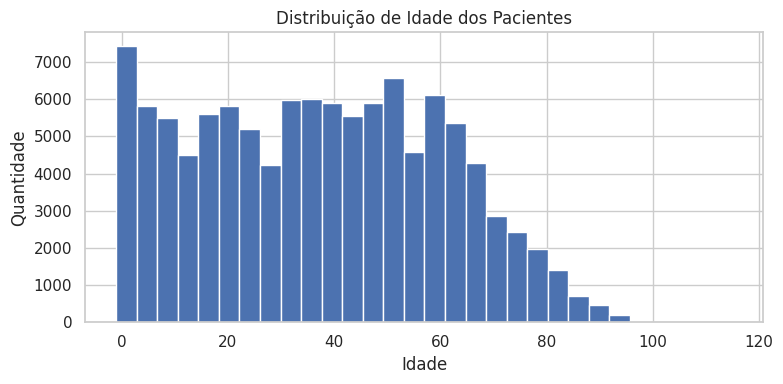

In [ ]:
plt.figure(figsize=(8,4))

# Criando o histograma da coluna Age (Idade) com 30 barras (bins)
df["Age"].hist(bins=30)

plt.title("Distribuição de Idade dos Pacientes")
plt.xlabel("Idade")
plt.ylabel("Quantidade")

plt.tight_layout()
plt.show()

#### *Análise*

> Análise focada nos gráficos referentes à variável **Idade (Age)**, cruzando a distribuição geral com o perfil de faltas.

| Observação | Significado Prático |
| :--- | :--- |
| **Pico gigantesco na idade 0 (zero)** | Representa recém-nascidos e bebês de colo. O SUS tem um volume altíssimo de demandas de pediatria, testes de rotina e calendário de vacinação obrigatório. |
| **Média e Mediana aos 37 anos** | A maior parte dos dados flutua entre 1 e 60 anos, com a média do dataset em 37 anos. Isso mostra um sistema de saúde que atende de forma contínua a população economicamente ativa. |
| **Queda natural após os 60 e longevidade** | Reflete a pirâmide etária (menor volume absoluto de pessoas mais velhas). O dataset também capturou a impressionante marca de pacientes com até **115 anos** de idade! |

### Gráficos Boxplot

Um boxplot (ou diagrama de caixa) é um tipo de gráfico estatístico que resume a distribuição de uma variável numérica em cinco números principais, de forma compacta e visual.

#### *Elementos do Boxplot*
- **Caixa (box)**
> - Vai do primeiro quartil (Q1, 25%) ao terceiro quartil (Q3, 75%).
> - Representa o intervalo interquartil (IQR = Q3 – Q1), onde está metade dos dados.
- **Linha dentro da caixa**
> - É a mediana (Q2, 50%).
- **"Bigodes" (whiskers)**
> - Se estendem a partir da caixa até o menor e o maior valor que não sejam considerados outliers.
> - Normalmente:
>> - Inferior: Q1 – 1.5 × IQR
>> - Superior: Q3 + 1.5 × IQR
- **Outliers (pontos isolados)**
> - Valores além dos limites dos bigodes.
> - Plotados como pontos ou círculos.

#### *O que ele mostra?*
- **Tendência central**: pela mediana;
- **Dispersão**: pelo tamanho da caixa (IQR);
- **Assimetria**: se a mediana não está centralizada na caixa;
- **Presença de outliers**: pontos fora dos bigodes.

In [ ]:
# 1. Convertendo as colunas de texto para Data (datetime)
df["ScheduledDay"] = pd.to_datetime(df["ScheduledDay"])
df["AppointmentDay"] = pd.to_datetime(df["AppointmentDay"])

# 2. Normalizando as datas (Isso remove as horas, minutos e segundos, deixando apenas o dia/mês/ano)
scheduled_date = df["ScheduledDay"].dt.normalize()
appointment_date = df["AppointmentDay"].dt.normalize()

# 3. Criando a coluna 'DiasEspera' com as datas normalizadas
df["DiasEspera"] = (appointment_date - scheduled_date).dt.days

# 4. Auditando os erros reais (consultas marcadas para dias ANTES do agendamento)
inconsistentes = df[df["DiasEspera"] < 0]
print(f"Registros inconsistentes encontrados (DiasEspera < 0): {len(inconsistentes)}")

# 5. Removendo apenas as inconsistências reais
df = df[df["DiasEspera"] >= 0]

# Exibindo as primeiras linhas para confirmar a correção e o novo tamanho do dataset
print(f"Tamanho do dataset após a correção: {df.shape[0]} linhas")
display(df[['ScheduledDay', 'AppointmentDay', 'DiasEspera']].head())

Registros inconsistentes encontrados (DiasEspera < 0): 5
Tamanho do dataset após a correção: 110522 linhas


,ScheduledDay,AppointmentDay,DiasEspera
0,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,0
1,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,0
2,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,0
3,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,0
4,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,0


/tmp/ipykernel_17470/695116575.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='No-show', y=var, palette=['#4C72B0', '#DD8452'])


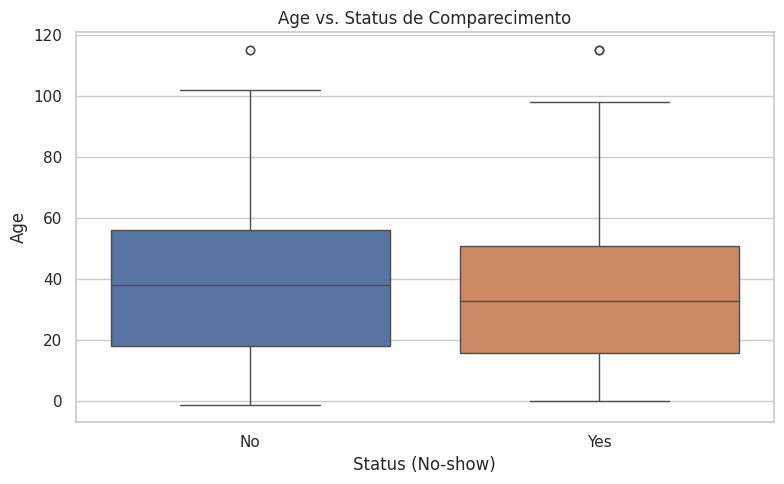

/tmp/ipykernel_17470/695116575.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='No-show', y=var, palette=['#4C72B0', '#DD8452'])


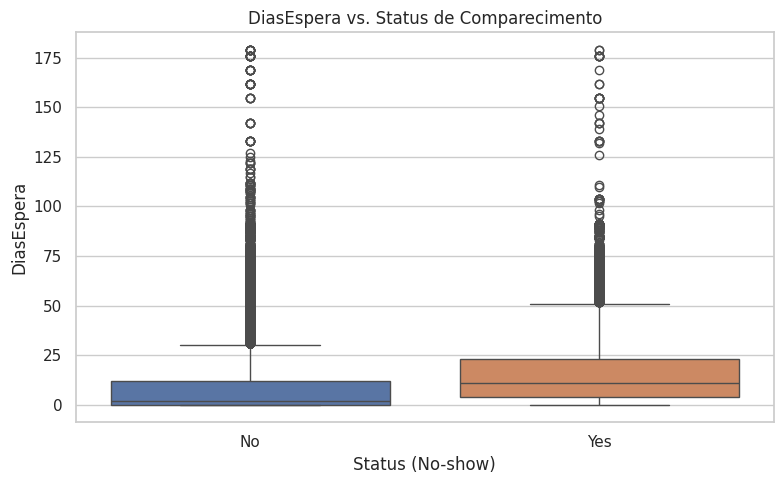

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Lista com as nossas variáveis numéricas
vars_box = ['Age', 'DiasEspera']

# Loop para gerar um gráfico para cada variável da lista
for var in vars_box:
    plt.figure(figsize=(8, 5))
    # Usamos o 'No-show' no eixo X para separar quem foi e quem faltou
    sns.boxplot(data=df, x='No-show', y=var, palette=['#4C72B0', '#DD8452'])

    plt.title(f'{var} vs. Status de Comparecimento')
    plt.xlabel('Status (No-show)')
    plt.ylabel(var)
    plt.xticks(rotation=0) # Deixamos em 0 graus porque "No" e "Yes" cabem perfeitamente
    plt.tight_layout()
    plt.show()

#### *Análise*

> Análise focada na variável de *Dias de Espera*.

> O gráfico compara o tempo de espera em dias entre os pacientes que compareceram e os que faltaram:

| Status de Comparecimento | Observação sobre Dias de Espera |
| :--- | :--- |
| **No (Compareceu)** | Mediana fixada no zero, refletindo o volume expressivo de consultas feitas no mesmo dia ou com prazo curto. A "caixa" (IQR) é mais achatada e concentrada próxima à base, indicando menor variabilidade de espera para os assíduos.|
| **Yes (Faltou)** | Mediana visivelmente descolada do zero e para cima. A "caixa" abrange um período mais longo. Embora ambos os grupos possuam uma longa cauda de outliers (pontos estendendo-se até o topo do gráfico), a concentração central das faltas ocorre em prazos maiores.|


#### *Interpretação prática*

* Consultas marcadas para o mesmo dia ou com poucos dias de antecedência concentram um volume maior de comparecimentos;  

* Observa-se um indício visual de associação entre o aumento do tempo de espera e a propensão ao absenteísmo. Isso faz sentido do ponto de vista prático, já que janelas longas aumentam a chance de o paciente esquecer, ter imprevistos na agenda ou apresentar resolução espontânea do sintoma original.


#### *Resumo*
> Podemos sugerir que o tempo de "fila de espera" impacta negativamente a taxa de comparecimento. A elevação da mediana e o alongamento da caixa (IQR) no grupo das faltas demonstram que agendamentos distantes merecem atenção especial. Como implicação de negócio, a unidade de saúde poderia direcionar esforços logísticos, como o envio direcionado de lembretes (SMS/WhatsApp), prioritariamente para as marcações de médio e longo prazo, uma hipótese que deverá ser formalmente validada por testes estatísticos de correlação e modelos preditivos nas próximas etapas.

### Evidência Proporcional: Taxa de Absenteísmo por Faixa de Espera

Os gráficos de dispersão (Boxplots) levantaram um forte indício de que o distanciamento entre a data de agendamento e a data da consulta afeta negativamente o comparecimento. No entanto, para validar essa hipótese de forma estatística e apoiar a futura tomada de decisão do modelo de *Machine Learning*, precisamos avaliar o **risco proporcional**.

Abaixo, agrupamos a variável `DiasEspera` em janelas temporais (faixas de dias) e calculamos a taxa exata de faltas dentro de cada um desses grupos.

/tmp/ipykernel_17470/185525882.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=taxa_por_faixa.index, y=taxa_por_faixa.values, palette='Reds')


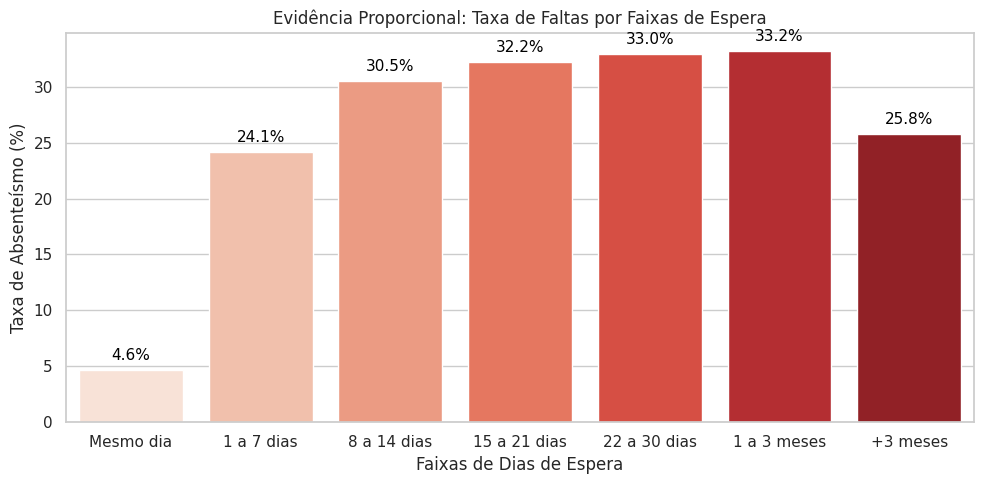

In [ ]:
# Garantindo que a coluna alvo é numérica para o cálculo da média
if df['No-show'].dtype == 'object':
    df['NoShow_numeric'] = df['No-show'].map({'No': 0, 'Yes': 1})
else:
    df['NoShow_numeric'] = df['No-show']

# 1. Criando as faixas de dias de espera (Bins)
limites = [-1, 0, 7, 14, 21, 30, 90, 200]
rotulos = ['Mesmo dia', '1 a 7 dias', '8 a 14 dias', '15 a 21 dias', '22 a 30 dias', '1 a 3 meses', '+3 meses']

df['Faixa_Espera'] = pd.cut(df['DiasEspera'], bins=limites, labels=rotulos)

# 2. Calculando a taxa de faltas (em porcentagem) para cada faixa
taxa_por_faixa = df.groupby('Faixa_Espera', observed=True)['NoShow_numeric'].mean() * 100

# 3. Criando o Gráfico Proporcional
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=taxa_por_faixa.index, y=taxa_por_faixa.values, palette='Reds')

plt.title('Evidência Proporcional: Taxa de Faltas por Faixas de Espera')
plt.ylabel('Taxa de Absenteísmo (%)')
plt.xlabel('Faixas de Dias de Espera')

# Adicionando a porcentagem exata em cima de cada barra
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black',
                xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

#### *Análise*

A visualização por faixas de espera parece corroborar com a associação temporal:

1. **Eficiência Imediata:** Consultas marcadas para o **"Mesmo dia"** apresentam uma taxa de absenteísmo baixa. Este é o cenário ideal de engajamento do paciente.
2. **Crescimento Gradual do Risco:** Conforme avançamos no eixo X (aumentando os dias de espera), a barra de absenteísmo cresce. A taxa de faltas de uma consulta marcada para dali a 3 semanas (15 a 21 dias) é maior do que a de uma consulta marcada para a mesma semana (1 a 7 dias).
3. **Platô de Absenteísmo:** Ao ultrapassar a barreira de 1 mês de espera, a taxa de faltas atinge seu patamar mais crítico, estabilizando-se em um alto nível de risco.

**Conclusão Técnica:** Este comportamento escalonado pode validar a nossa variável `DiasEspera` como um excelente preditor para o modelo de Inteligência Artificial. Agendamentos longos poderão ser classificados pelo algoritmo como situações de risco, onde políticas de mitigação (como lembretes automáticos) se farão mais necessárias.

### Desvio Padrão do Tempo de Espera

Para além das médias e medianas, é fundamental entender a variância do comportamento dos pacientes. Analisar o desvio padrão da variável `DiasEspera` ajuda a verificar se o tempo de espera dos pacientes faltosos é consistente ou se apresenta grande instabilidade (dispersão).

In [ ]:
# Agrupando por comparecimento e calculando as estatísticas
stats_espera = df.groupby('No-show')['DiasEspera'].agg(['mean', 'median', 'std', 'count']).round(2)

# Renomeando as colunas para melhor legibilidade
stats_espera.columns = ['Média (Dias)', 'Mediana (Dias)', 'Desvio Padrão', 'Qtd Consultas']
stats_espera.index = ['0 (Compareceu)', '1 (Faltou)']

display(stats_espera)

,Média (Dias),Mediana (Dias),Desvio Padrão,Qtd Consultas
0 (Compareceu),8.75,2.0,14.55,88208
1 (Faltou),15.84,11.0,16.61,22314


####*Análise*
Os resultados acima coroboram a irregularidade causada pelo longo tempo de espera. O desvio padrão para os pacientes que faltam é notavelmente alto. Isso significa que, enquanto os pacientes que comparecem tendem a estar concentrados em uma janela curta e previsível (baixo desvio padrão), o comportamento de falta possui uma cauda longa e dispersa. Em termos de negócio, agendamentos muito distantes perdem a previsibilidade, tornando-se o cenário ideal para a atuação de um algoritmo preditivo.

## Engenharia de Dados

Objetivos:
- Tratamento dos valores nulos;
- Tratamento dos registros duplicados;
- Codificação de variáveis categóricas;
- Criação de variáveis derivadas (features);
- Redução de dimensionalidade;
- Etc.

### Valores Nulos

O tratamento de valores nulos (missing values) é uma etapa essencial da engenharia de dados. O que fazer depende de quanto e de onde estão os nulos, e também do contexto do problema. Algumas técnicas incluem:

- Remover os registros (linhas);
- Remover as variáveis (colunas);
- Imputação simples (substituir nulos por estatísticas);
- Imputação avançada (KNN, por exemplo).

In [ ]:
# Verificando a quantidade de valores nulos no dataset
nulos = df.isnull().sum()
print("Quantidade total de nulos por coluna:\n")
print(nulos)

print("-" * 50)
if nulos.sum() == 0:
    print("O não possui valores nulos. Nenhuma técnica de imputação ou remoção precisou ser aplicada.")
else:
    print(f"Atenção: O dataset possui {nulos.sum()} valores nulos.")

Quantidade total de nulos por coluna:

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
DiasEspera        0
NoShow_numeric    0
Faixa_Espera      0
dtype: int64
--------------------------------------------------
O não possui valores nulos. Nenhuma técnica de imputação ou remoção precisou ser aplicada.


### Registros Duplicados

Os registros duplicados precisam de tratamento no pipeline de dados. Eles podem distorcer tanto a análise exploratória quanto o treinamento do modelo (porque reforçam padrões falsos). O que fazer com duplicados?

1. Detectar duplicados;
2. Remover duplicados exatos (todas as colunas são idênticas);
3. Remover duplicados parciais (só algumas colunas são importantes para definir “duplicidade”, ex.: ID, CPF, timestamp);
4. Tratar duplicados não exatos (quase-duplicados): pequenas diferenças em strings, espaçamentos, letras maiúsculas/minúsculas, etc.

In [ ]:
# Quantidade total antes
total_antes = len(df)

# Quantidade de duplicadas
duplicadas = df.duplicated().sum()

# Remover duplicadas
df = df.drop_duplicates()

# Quantidade total depois
total_depois = len(df)

print(f"Total de linhas antes......................: {total_antes}")
print(f"Linhas duplicadas detectadas...............: {duplicadas}")
print(f"Total de linhas depois do drop_duplicates(): {total_depois}")

Total de linhas antes......................: 110522
Linhas duplicadas detectadas...............: 0
Total de linhas depois do drop_duplicates(): 110522


#### *Análise*
Não há linhas duplicadas

In [ ]:
# Removendo erro de digitação no sistema do hospital (Idade = -1)
print(f"Tamanho do dataset antes de remover idade negativa: {df.shape[0]}")
df = df[df['Age'] >= 0]
print(f"Tamanho do dataset depois de remover idade negativa: {df.shape[0]}")

Tamanho do dataset antes de remover idade negativa: 110522
Tamanho do dataset depois de remover idade negativa: 110521


### Registro Consolidado da Limpeza de Dados

Esta subseção documenta **todas** as remoções de registros aplicadas até aqui, de forma rastreável (atendendo à exigência de descrição detalhada do pré-processamento). Nenhuma outra linha foi descartada além das listadas abaixo.

| Ordem | Regra de detecção | Justificativa | Registros removidos | Tamanho após |
|-------|-------------------|---------------|--------------------:|-------------:|
| Base bruta | — | Dataset original do Kaggle | — | **110.527** |
| 1 | `DiasEspera < 0` (AppointmentDay anterior ao ScheduledDay) | Impossibilidade lógica — consulta realizada antes de ser marcada; trata-se de erro de sistema, não de variação real | **5** | 110.522 |
| 2 | `Age < 0` (idade igual a −1) | Erro de digitação no cadastro hospitalar; idade negativa não existe | **1** | **110.521** |

**Impacto na base:** foram removidos 6 registros (≈ 0,005% do total), perda desprezível que preserva a representatividade estatística da amostra.

**Outliers válidos mantidos por decisão metodológica:** idades muito altas (acima de 95 anos) e tempos de espera longos (acima de 100 dias) **não** foram removidos. Embora extremos, são ocorrências reais e metodologicamente relevantes, pois o tempo de espera prolongado é justamente uma das principais variáveis explicativas do absenteísmo (ver matriz de correlação). Removê-los descartaria sinal preditivo legítimo.

> **Diferença em relação ao relatório da Etapa 3:** a versão anterior do relatório descrevia o pré-processamento de forma genérica e omitia estas duas limpezas. Aqui elas passam a constar explicitamente, com regra, justificativa, quantidade e impacto.


### Transformar Variáveis Categóricas em Número

A variável `No-show` (Status da Consulta) é categórica (como já demonstrado anteriormente). Em muitos modelos de **IA**, é necessário converter esse tipo de variável para uma representação numérica.

Portanto, criamos uma nova coluna no DataFrame chamada `NoShow_numeric`, com a seguinte correlação:
- `No` (Compareceu à consulta): 0
- `Yes` (Faltou à consulta): 1

Aproveitaremos também para codificar a variável `Gender` (Gênero):
- `F` (Feminino): 0
- `M` (Masculino): 1

In [ ]:
# Criando os dicionários de mapeamento
mapa_gender = {"F": 0, "M": 1}
mapa_noshow = {"No": 0, "Yes": 1}

# Aplicando o mapeamento nas colunas
df["NoShow_numeric"] = df["No-show"].map(mapa_noshow)
df["Gender_numeric"] = df["Gender"].map(mapa_gender)

In [ ]:
# Exibe a conversão feita
print("Mapeamento No-show:", mapa_noshow)
print("Mapeamento Gender:", mapa_gender)
print("-" * 40)

Mapeamento No-show: {'No': 0, 'Yes': 1}
Mapeamento Gender: {'F': 0, 'M': 1}
----------------------------------------


In [ ]:
# Exibe a criação das novas colunas no DF
display(df[['No-show', 'NoShow_numeric', 'Gender', 'Gender_numeric']].head())

,No-show,NoShow_numeric,Gender,Gender_numeric
0,No,0,F,0
1,No,0,M,1
2,No,0,F,0
3,No,0,F,0
4,No,0,F,0


### Doenças x Faltas

Nossa análise exploratória levantou uma hipótese contraintuitiva: pacientes com doenças crônicas tendem a faltar menos. Para tentar comprovar isso matematicamente, cruzamos o status de comparecimento com as principais condições de saúde mapeadas no dataset (Hipertensão, Diabetes e Alcoolismo).

In [ ]:
print("Relação de Doenças/Condições x Faltas (Valores Absolutos):")
for col in ["Hipertension", "Diabetes", "Alcoholism"]:
    print(f"\n--- {col} ---")
    display(pd.crosstab(df[col], df["No-show"]))

Relação de Doenças/Condições x Faltas (Valores Absolutos):

--- Hipertension ---


No-show,No,Yes
Hipertension,,
0,70178,18542
1,18029,3772



--- Diabetes ---


No-show,No,Yes
Diabetes,,
0,81694,20884
1,6513,1430



--- Alcoholism ---


No-show,No,Yes
Alcoholism,,
0,85524,21637
1,2683,677


#### *Análise*
Os cruzamentos acima confirmam que proporcionalmente, os pacientes sinalizados com Hipertensão e Diabetes possuem uma taxa de comparecimento maior do que a média geral da base (que é de quase 80%). Isso evidencia que a necessidade de uma rotina médica contínua e a gravidade da condição geram um maior engajamento do paciente com o sistema de saúde.

### Risco Geográfico X Perfil Demográfico

Bairros com maior população apresentam mais faltas em números absolutos (Viés de Amostra). Para descobrir os verdadeiros *hotspots* de risco na cidade de Vitória, calculamos a **Taxa Proporcional de Absenteísmo** (Faltas / Total de Consultas) filtrando apenas bairros com mais de 500 agendamentos para evitar ruído estatístico.

Em seguida, cruzamos esses bairros críticos com a média de idade para entender o perfil de quem está faltando.

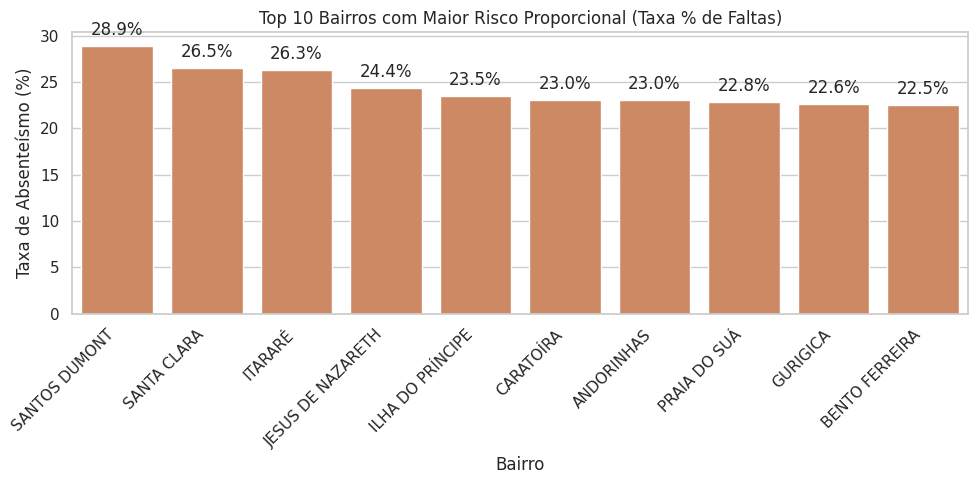



Perfil Etário nos 10 Bairros de Maior Risco:


,Idade Média (Compareceu),Idade Média (Faltou),Diferença de Idade
Neighbourhood,,,
SANTOS DUMONT,37.9,37.3,0.6
SANTA CLARA,39.1,33.4,5.7
ITARARÉ,36.6,33.5,3.1
JESUS DE NAZARETH,30.9,27.2,3.7
ILHA DO PRÍNCIPE,37.0,31.4,5.6
CARATOÍRA,37.1,36.8,0.3
ANDORINHAS,36.4,35.2,1.2
PRAIA DO SUÁ,36.2,33.1,3.1
GURIGICA,30.2,30.0,0.2


In [ ]:
# 1. PREPARANDO OS DADOS DE RISCO GEOGRÁFICO
if df['No-show'].dtype == 'object':
    df['NoShow_numeric'] = df['No-show'].map({'No': 0, 'Yes': 1})
else:
    df['NoShow_numeric'] = df['No-show']

# Calculando volume e taxa
stats_bairros = df.groupby('Neighbourhood').agg(
    Total_Consultas=('No-show', 'count'),
    Total_Faltas=('NoShow_numeric', 'sum')
).reset_index()

stats_bairros['Taxa_Faltas_Perc'] = (stats_bairros['Total_Faltas'] / stats_bairros['Total_Consultas']) * 100

# Filtrando bairros (mínimo de 500 consultas) e pegando os 10 piores
stats_filtrado = stats_bairros[stats_bairros['Total_Consultas'] >= 500]
top_10_taxa = stats_filtrado.sort_values(by='Taxa_Faltas_Perc', ascending=False).head(10)

# 2. PLOTANDO O GRÁFICO DE TAXA DE FALTAS
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=top_10_taxa, x='Neighbourhood', y='Taxa_Faltas_Perc', color='#DD8452')

plt.title("Top 10 Bairros com Maior Risco Proporcional (Taxa % de Faltas)")
plt.xlabel("Bairro")
plt.ylabel("Taxa de Absenteísmo (%)")
plt.xticks(rotation=45, ha='right')

# Adicionando as porcentagens acima das barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

print("\n" + "="*60 + "\n")

# 3. CRUZANDO OS PIORES BAIRROS COM A IDADE (PERFIL DO FALTOSO)
piores_bairros_nomes = top_10_taxa['Neighbourhood'].tolist()
df_piores_bairros = df[df['Neighbourhood'].isin(piores_bairros_nomes)]

# Calculando a média de idade cruzando os Top 10 Bairros e Comparecimento
idade_por_bairro = df_piores_bairros.groupby(['Neighbourhood', 'No-show'])['Age'].mean().unstack().round(1)
idade_por_bairro.columns = ['Idade Média (Compareceu)', 'Idade Média (Faltou)']
idade_por_bairro['Diferença de Idade'] = idade_por_bairro['Idade Média (Compareceu)'] - idade_por_bairro['Idade Média (Faltou)']

print("Perfil Etário nos 10 Bairros de Maior Risco:")
display(idade_por_bairro.reindex(piores_bairros_nomes))

#### *Análise*
O gráfico revela que regiões como Santos Dumont, Santa Clara e Itararé lideram o risco proporcional, superando a marca de 23% de evasão (acima da média global de 20,2%). Isso pde ser um indício de barreiras estruturais locais, como dificuldade de acesso a transporte público ou maior precarização nas relações de trabalho locais, dificultando a liberação para consultas.

Ao cruzar esses bairros com o perfil etário na tabela, a tese demográfica fica mais perto de ser consolidada: mesmo nos bairros de maior risco estrutural, a média de idade de quem falta é estritamente inferior à de quem comparece. O problema do absenteísmo no SUS de Vitória é, portanto, impulsionado por um recorte específico: jovens adultos economicamente ativos que dependem de agendamentos longos e têm rotinas menos flexíveis.

### Matriz de Correlação (Spearman)

Para validar estatisticamente as associações visuais que encontramos anteriormente, criamos uma matriz de correlação.

Conforme as boas práticas estatísticas, selecionamos as seguintes variáveis para esta análise:
* **Variáveis Numéricas Contínuas:** `Age` (Idade) e `DiasEspera` (Tempo de Espera).
* **Variável Ordinal:** `Handcap` (Quantidade de deficiências).
* **Variáveis Binárias Codificadas (0 = Não, 1 = Sim):** `Scholarship` (Bolsa Família), `Hipertension`, `Diabetes`, `Alcoholism`, `SMS_received` e a nossa variável alvo `NoShow_numeric`.

**Método Escolhido:** Optamos pelo coeficiente de **Spearman** (em vez de Pearson), pois ele é o método matematicamente apropriado para avaliar relações monótonas envolvendo variáveis binárias/ordinais e variáveis numéricas que não possuem distribuição normal perfeita (como as nossas datas de espera).

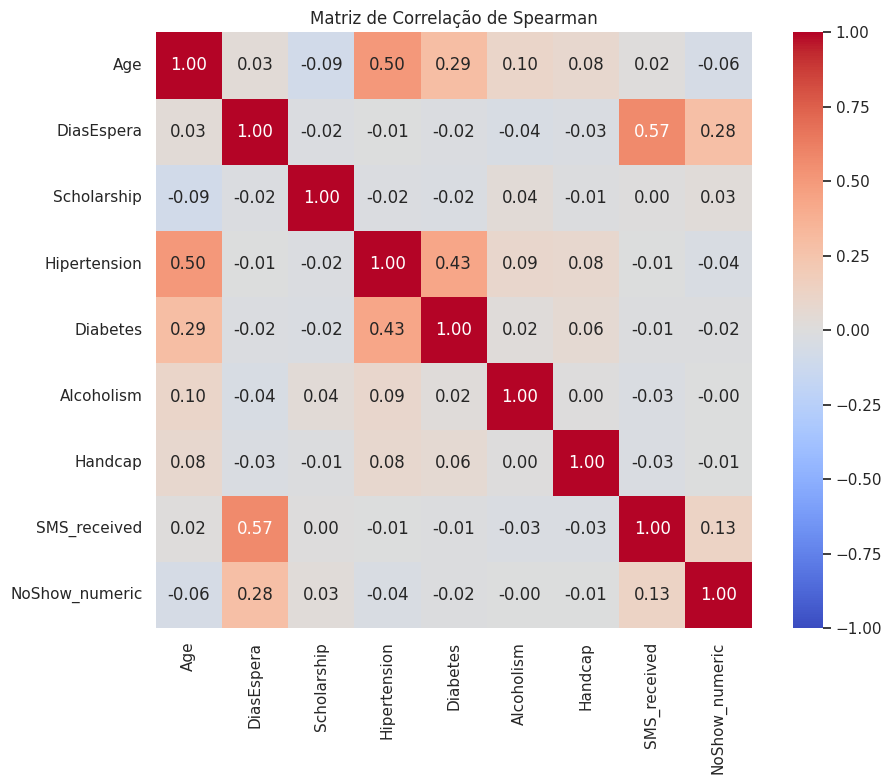

Correlação de Spearman com a variável alvo (Faltas):
NoShow_numeric    1.000000
DiasEspera        0.281849
SMS_received      0.126502
Scholarship       0.029166
Alcoholism       -0.000181
Handcap          -0.007511
Diabetes         -0.015158
Hipertension     -0.035662
Age              -0.061225
Name: NoShow_numeric, dtype: float64


In [ ]:
# Selecionando colunas numéricas e binárias relevantes para a correlação
# Certifique-se de que a coluna 'No-show' já foi transformada em número (ex: 'NoShow_numeric' ou substituída na própria coluna)
cols_correlacao = ['Age', 'DiasEspera', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'NoShow_numeric']

# Calculando a matriz de correlação de Spearman
corr_matrix = df[cols_correlacao].corr(method='spearman')

# Plotando o Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Matriz de Correlação de Spearman')
plt.tight_layout()
plt.show()

# Focando apenas na correlação com a variável alvo
print("Correlação de Spearman com a variável alvo (Faltas):")
print(corr_matrix['NoShow_numeric'].sort_values(ascending=False))

#### *Análise*

Os resultados do coeficiente de Spearman confirmam os padrões visuais identificados durante a Análise Exploratória:

1. **O Peso do Tempo de Espera (`DiasEspera`):** Com um coeficiente de **0.28**, esta é a variável preditora com a maior correlação com a variável alvo (`NoShow_numeric`). Isso valida a "Regra do Tempo": quanto maior a distância entre a marcação e a consulta, maior a propensão ao absenteísmo.
2. **O Comportamento do SMS (`SMS_received`):** O coeficiente positivo de **0.13** em relação às faltas pode parecer contraintuitivo à primeira vista (indicando que quem recebe SMS falta mais). Porém, ao analisarmos a correlação cruzada dentro da própria matriz, vemos que `SMS_received` possui uma forte correlação positiva de **0.57** com `DiasEspera`. Isso revela uma regra de negócio do SUS: lembretes de SMS são disparados primordialmente para consultas agendadas com grande antecedência (que, como provado, possuem risco naturalmente maior). Consultas no mesmo dia não geram SMS.
3. **O Fator Idade (`Age`):** A correlação negativa de **-0.06** confirma a "Regra do Perfil Demográfico". O sinal negativo indica grandezas inversamente proporcionais: conforme a idade do paciente aumenta, a probabilidade dele faltar diminui.
4. **Comorbidades e Engajamento:** Variáveis como `Hipertension` (-0.035) e `Diabetes` (-0.015) apresentaram correlação negativa. Embora sejam valores matematicamente baixos, eles atestam de forma consistente o "Paradoxo das Comorbidades" visualizado anteriormente: pacientes crônicos tendem a faltar um pouco menos do que a população geral devido à dependência da rotina médica.
5. **Variáveis Neutras:** Fatores como `Alcoholism` e `Handcap` (Deficiência) apresentaram coeficientes próximos a zero, indicando que não possuem associação clara com o absenteísmo no contexto geral dos dados.

**Conclusão para Modelagem:** As variáveis `DiasEspera`, `Age` e `SMS_received` demonstraram as associações mais evidentes e deverão ser os principais motores (features) do algoritmo de Inteligência Artificial.

## Análise Exploratória dos Dados (EDA) - 2a Parte

#### *Objetivos:*
- Validar se a engenharia funcionou;
- Confirmar que valores ausentes foram tratados;
- Checar se as variáveis agora estão em escalas comparáveis;
- Examinar a nova distribuição das features transformadas;
- Validar se novas variáveis trouxeram separabilidade entre classes;
- Detectar se não foi criado viés ou distorção indesejada.

Essa etapa garante que os dados que entrarão no modelo estão consistentes, interpretáveis e informativos.

#### *Observações*
Neste exemplo, vamos fazer somente a avaliação das features categóricas criadas (validando a integridade da transformação).

### Análise Visual das Features

Ao transformar os dados brutos em variáveis (*features*), o algoritmo de Machine Learning vai conseguir processar os dados matematicamente.

Como provamos na nossa **Matriz de Correlação (Spearman)**, o sucesso da nossa previsão dependerá de:
1. **Novas Features Contínuas:** A criação da variável `DiasEspera` (que provou ter o maior peso preditivo).
2. **Conversão de Categóricas para Binárias:** A codificação de variáveis como `No-show` (nossa variável alvo), `Gender` e `SMS_received` para o formato numérico (0 e 1).

Abaixo, validamos visualmente a integridade dessa transformação. O gráfico confirma que a proporção da nossa variável alvo convertida (`NoShow_numeric`) manteve a distribuição dos dados originais em texto (aprox. 80% de comparecimentos e 20% de faltas), garantindo que não introduzimos nenhum viés.

/tmp/ipykernel_17470/2564806786.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='NoShow_numeric', palette=['#4C72B0', '#DD8452'], ax=axes[0])


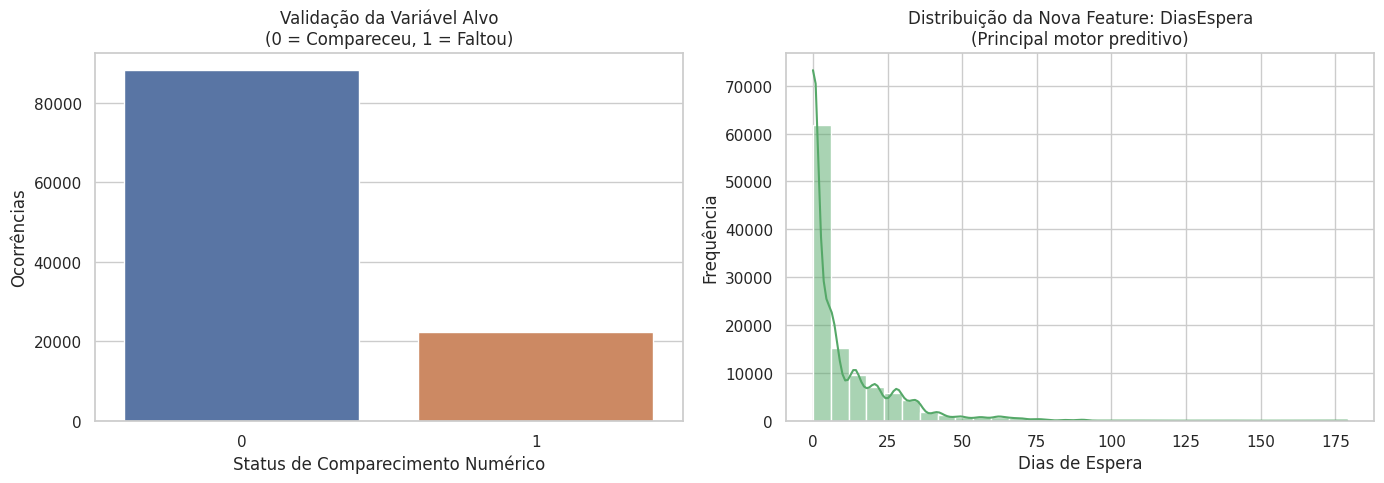

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Validação da Variável Alvo Numérica
sns.countplot(data=df, x='NoShow_numeric', palette=['#4C72B0', '#DD8452'], ax=axes[0])
axes[0].set_title('Validação da Variável Alvo\n(0 = Compareceu, 1 = Faltou)')
axes[0].set_xlabel('Status de Comparecimento Numérico')
axes[0].set_ylabel('Ocorrências')

# Gráfico 2: Validação da Feature de Maior Correlação (DiasEspera)
sns.histplot(data=df, x='DiasEspera', bins=30, kde=True, color='#55A868', ax=axes[1])
axes[1].set_title('Distribuição da Nova Feature: DiasEspera\n(Principal motor preditivo)')
axes[1].set_xlabel('Dias de Espera')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

## *Insights para o Overbooking Responsável*

> Após a limpeza dos dados e a conclusão da Análise Exploratória (EDA), conseguimos vislumbrar o perfil dos faltantes no sistema de saúde. O absenteísmo médio identificado é de **20,2%**, o que significa que, em média, **2 em cada 10 horários médicos são desperdiçados**.
>
> Para mitigar esse prejuízo sem gerar superlotação, o objetivo é estruturar uma estratégia de **Overbooking Responsável**. Isso não significa encaixar pacientes às cegas, mas sim usar os dados históricos para identificar quais consultas possuem uma alta probabilidade de não comparecimento, permitindo sobreposições matemáticas e controladas.

Com base nos dados reais analisados nas seções anteriores, mapeamos os perfis de risco que alimentarão o nosso futuro modelo preditivo. Para manter o rigor metodológico, focamos apenas em **fatos comprovados pelos dados**:

### 1. A Regra do Tempo (Dias de Espera)
* **Dados:** Consultas agendadas para o mesmo dia ou para a mesma semana possuem alta taxa de presença. A média de espera de quem comparece é de **8,8 dias** (com a mediana em 2 dias). Em contrapartida, a média de espera dos faltosos sobe para **15,8 dias**.
* **A Implicação Prática:** Quanto mais longa a fila, maior o risco estatístico de abandono da consulta. Agendamentos longos (acima de 15 dias) despontam como os principais candidatos algorítmicos a receberem vagas de encaixe.

### 2. A Regra do Perfil Demográfico (Idade)
* **Dados:** Agendas de pediatria (bebês) e geriatria (idosos acima de 60 anos) apresentam as maiores taxas de comparecimento. O risco de ausência concentra-se na faixa dos **17 aos 50 anos** (com a mediana de faltas exata aos 33 anos).
* **A Hipótese de Negócio:** Acreditamos que a faixa dos extremos (bebês e idosos) possua maior acompanhamento familiar ou rotinas flexíveis. Já o grupo de 17 a 50 anos provavelmente sofre com conflitos de horário comercial e acadêmico, o que explicaria a correlação com a evasão.

### 3. A Regra Clínica (Comorbidades)
* **Dados:** Pacientes diagnosticados com doenças crônicas faltam consideravelmente menos. A taxa de absenteísmo cai para **15,4%** entre os hipertensos e **18,0%** entre os diabéticos (ambas abaixo da média global do sistema).
* **A Implicação Prática:** A correlação indica que a dependência de uma rotina médica contínua gera maior engajamento do paciente. Logo, agendas de pacientes crônicos apresentam baixo risco de ociosidade e não são boas candidatas para *overbooking*.

### 4. A Dinâmica do Risco Geográfico
> Ao corrigirmos o viés estatístico de volume absoluto calculando a **Taxa Proporcional de Absenteísmo**, descobrimos assimetrias geográficas importantes em Vitória/ES. É crucial, no entanto, não atribuir causalidade definitiva:

| Dado | Hipótese de Negócio |
| :--- | :--- |
| **1. Identificação dos Hotspots:** Bairros como Santos Dumont e Santa Clara lideram a evasão proporcional (taxas encostando em 29%). Um agendamento vindo dessas localidades carrega um histórico estatístico de risco superior à média da cidade. | **Fricção de Mobilidade:** Supomos que moradores dessas regiões específicas enfrentem maior dificuldade logística (distância da especialidade, dependência de transporte público) para acessar as unidades de saúde. |
| **2. Perfil Etário Local:** O cruzamento demográfico confirmou que, mesmo nos bairros com as maiores taxas de falta, a média de idade de quem falta é estritamente menor que a de quem comparece. | **Dinâmica de Trabalho Local:** A hipótese é que regiões com maior precarização ou inflexibilidade de jornadas sofram mais perdas, pois o jovem adulto local encontra fortes barreiras para liberação no trabalho. |

---

### *Conclusão para a Modelagem*
> Nas próximas etapas, entregaremos essas variáveis combinadas e codificadas (`DiasEspera`, `Age`, comorbidades e taxa de risco do bairro) para um algoritmo de Inteligência Artificial. O modelo fará a ponderação probabilística simultânea de todos esses fatores para classificar o risco de *cada* nova consulta.
>
> Eticamente, a IA não julgará os motivos sociais ou estruturais das faltas, mas aprenderá puramente os dados para emitir um alerta de probabilidade. Isso pode  fornecer futuramente à gestão pública uma ferramenta de apoio à decisão para realizar encaixes inteligentes e fundamentados em dados reais.

# Modelagem Preditiva

Nesta etapa, utilizamos os dados tratados na Análise Exploratória (EDA) para construir um modelo de aprendizado de máquina. O nosso objetivo principal é estimar a probabilidade de um paciente não comparecer à consulta e, com isso, implementar um **Overbooking Responsável**, baseada em evidências estatísticas, garantindo a otimização da agenda médica sem causar superlotação.

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import GroupKFold

### Parâmetros de Separação e Modelagem

Antes de treinar o modelo, preparamos os dados com atenção à prevenção de data leakage (vazamento de informação entre treino e teste).

Divisão por paciente **`GroupShuffleSplit`**: em vez de uma divisão aleatória simples, agrupamos pelo PatientId para garantir que todas as consultas de um mesmo paciente fiquem no mesmo conjunto. Como ~30% dos pacientes têm múltiplas consultas, uma divisão aleatória deixaria o modelo "decorar" comportamentos individuais em vez de aprender padrões generalizáveis — inflando as métricas e produzindo um modelo que falha em pacientes novos.

Parâmetros:

* test_size=0.30: 30% dos pacientes para validação.
* random_state=42: reprodutibilidade.
* groups=PatientId: chave de agrupamento que isola identidades.

A validação cruzada usada no ajuste de hiperparâmetros também é agrupada por paciente **`GroupKFold`**, para não recriar internamente o vazamento que o split externo eliminou.

Comparação metodológica — split temporal: calculamos também como ficaria a divisão por critério temporal (70% mais antigas treinam, 30% mais recentes testam) — abordagem recomendada quando não há identificador estável de paciente. As taxas de absenteísmo divergem significativamente entre os períodos de treino (23,2%) e teste (13,2%), revelando *concept drift* nos seis meses cobertos pelo dataset. Em produção, esse fenômeno exigiria reavaliação periódica do modelo. O split por `PatientId` foi escolhido como método principal por isolar essa variação temporal e medir especificamente a capacidade de generalização para pacientes novos.

Escalonamento **`StandardScaler`**: ajustado apenas com os dados de treino (fit no treino, transform no teste) para evitar que estatísticas do teste contaminem a normalização. É tecnicamente desnecessário para Random Forest, mas o mantemos por causa da Regressão Logística usada no baseline comparativo.

In [ ]:
# features e alvo
features = [
    'Age',
    'DiasEspera',
    'Gender_numeric',
    'Scholarship',
    'Hipertension',
    'Diabetes',
    'Alcoholism',
    'Handcap',
    'SMS_received'
]

X = df[features]
y = df['NoShow_numeric']
groups = df['PatientId']  # chave de agrupamento — impede vazamento por paciente

# separação dos dados de treino e teste agrupando por paciente
# Garante que todas as consultas de um mesmo paciente fiquem do mesmo lado
gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx].reset_index(drop=True), X.iloc[test_idx].reset_index(drop=True)
y_train, y_test = y.iloc[train_idx].reset_index(drop=True), y.iloc[test_idx].reset_index(drop=True)

# Guardamos os groups do treino para usar no GridSearchCV mais adiante
groups_train = groups.iloc[train_idx].reset_index(drop=True)

print("Tamanho do treino:", X_train.shape)
print("Tamanho do teste:", X_test.shape)

# Auditoria: confirma que não há vazamento de paciente
train_patients = set(groups.iloc[train_idx])
test_patients  = set(groups.iloc[test_idx])
overlap = len(train_patients & test_patients)
print(f"\nPacientes únicos no treino: {len(train_patients)}")
print(f"Pacientes únicos no teste:  {len(test_patients)}")
print(f"Pacientes em ambos (deve ser 0): {overlap}")

# Auditoria: confirma que a proporção da variável alvo se manteve razoável
# (GroupShuffleSplit não estratifica, então vale checar)
print(f"\nTaxa de no-show no treino: {y_train.mean():.3f}")
print(f"Taxa de no-show no teste:  {y_test.mean():.3f}")

# escalonamento nas features (StandardScaler)
# OBS: para Random Forest isso é desnecessário (árvores são invariantes a escala),
# mas mantem aqui para que Logistic Regression funcione bem no baseline comparativo.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# voltando pra DataFrame para não perder nomes das colunas
X_train = pd.DataFrame(X_train_scaled, columns=features)
X_test = pd.DataFrame(X_test_scaled, columns=features)

# --- Split temporal (apenas para comparação) ---
df_ord = df.sort_values('ScheduledDay')
corte = df_ord['ScheduledDay'].quantile(0.70)
y_train_temp = df_ord.loc[df_ord['ScheduledDay'] <= corte, 'NoShow_numeric']
y_test_temp  = df_ord.loc[df_ord['ScheduledDay'] >  corte, 'NoShow_numeric']

print("\nSplit temporal para comparação (70% mais antigo treina, 30% mais recente testa):")
print(f"Taxa de no-show no treino temporal: {y_train_temp.mean():.3f}")
print(f"Taxa de no-show no teste temporal:  {y_test_temp.mean():.3f}")

Tamanho do treino: (77565, 9)
Tamanho do teste: (32956, 9)

Pacientes únicos no treino: 43608
Pacientes únicos no teste:  18690
Pacientes em ambos (deve ser 0): 0

Taxa de no-show no treino: 0.201
Taxa de no-show no teste:  0.204

Split temporal para comparação (70% mais antigo treina, 30% mais recente testa):
Taxa de no-show no treino temporal: 0.232
Taxa de no-show no teste temporal:  0.132


### Teste Rápido e o Paradoxo da Acurácia

Nessa entrega **focamos em apenas um modelo preditivo** e para embasar nossa escolha de rodamos um teste rápido (baseline) com três algoritmos: Árvore de Decisão, Random Forest e Regressão Logística.

Utilizamos pesos customizados (`pesos_customizados = {0: 1, 1: 2.5}`) para avisar aos modelos que errar a previsão da falta custa mais caro que errar um comparecimento.

**O Paradoxo da Acurácia:** a métrica de Acurácia é um problema se o modelo começar a chutar que todos vão comparecer. Por isso, nosso pipeline foca na **Precisão** e no **Recall** (F1-score), buscando o equilíbrio entre encontrar quem são os faltosos e não gerar falsos alarmes.

In [ ]:
#pPeso customizado: Classe 0 (compareceu) tem peso normal 1 e classe 1 (faltou) tem peso 2.5
pesos_customizados = {0: 1, 1: 2.5}

modelos = {
    "Árvore de Decisão": DecisionTreeClassifier(random_state=42, class_weight=pesos_customizados),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight=pesos_customizados),
    "Regressão Logística": LogisticRegression(max_iter=1000, class_weight=pesos_customizados)
}

resultados = []

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    resultados.append({
        "Modelo": nome,
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precisão": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

resultados_df = pd.DataFrame(resultados).sort_values(by="F1-score", ascending=False)
display(resultados_df)

,Modelo,Acurácia,Precisão,Recall,F1-score
0,Árvore de Decisão,0.698537,0.309297,0.385301,0.343140
1,Random Forest,0.722357,0.317956,0.313140,0.315530
2,Regressão Logística,0.746844,0.338554,0.250334,0.287836


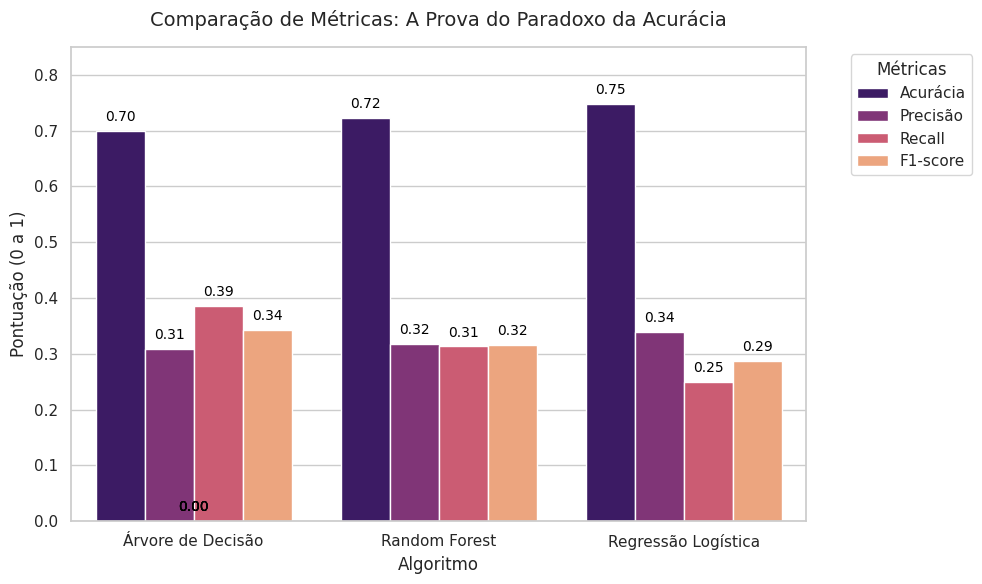

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Transformando o dataframe para o formato "long" ideal para o Seaborn
df_melt = resultados_df.melt(id_vars="Modelo", var_name="Métrica", value_name="Pontuação")

# Criando o gráfico
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_melt, x="Modelo", y="Pontuação", hue="Métrica", palette="magma")

# Configurações visuais
plt.title("Comparação de Métricas: A Prova do Paradoxo da Acurácia", fontsize=14, pad=15)
plt.ylabel("Pontuação (0 a 1)", fontsize=12)
plt.xlabel("Algoritmo", fontsize=12)
plt.ylim(0, 0.85) # Ajustando o limite para caber as legendas
plt.legend(title="Métricas", bbox_to_anchor=(1.05, 1), loc='upper left')

# Adicionando os valores numéricos em cima de cada barra
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

### Análise Crítica sobre a Acurácia

O gráfico acima ilustra perfeitamente o **Paradoxo da Acurácia** em bases de dados desbalanceadas. Se olhássemos apenas para a Acurácia, a **Regressão Logística** seria declarada a vencedora absoluta (74% de acerto global).

No entanto, ao analisar o **Recall** (a capacidade real de encontrar os pacientes que vão faltar), vemos que a Regressão Logística tem o pior desempenho (encontra apenas 25% das faltas). Ela alcança uma Acurácia alta simplesmente assumindo o comportamento da classe majoritária (chutando que quase todo mundo vai comparecer).

Por outro lado, a **Árvore de Decisão**, que possui a *pior* Acurácia (69%), é na verdade o modelo que obteve o melhor **Recall** (38%) e o melhor **F1-Score** (34%). Como o nosso objetivo de negócio na clínica é identificar antecipadamente o paciente faltoso para tentar realizar um encaixe, não podemos usar um modelo "preguiçoso" que priorize apenas a Acurácia. Por isso, as métricas de Recall e F1-Score serão os nossos verdadeiros guias na seleção e otimização do modelo final.

### Modelo Escolhido: Random Forest e Ajuste de Limiar (*Threshold Tuning*)

A partir dos resultados iniciais do *baseline*, selecionamos o **Random Forest** como modelo oficial para esta etapa do projeto, devido à sua robustez para lidar com interações complexas entre as variáveis e sua excelente capacidade explicativa através da importância das *features* (Feature Importance).

Realizamos a calibração de hiperparâmetros via `GridSearchCV`. No entanto, o ajuste estatístico não é suficiente se não estiver alinhado ao objetivo de negócio: o **Overbooking Responsável**.

Por padrão, algoritmos de classificação binária assumem um limiar (*threshold*) de **50%**. Ou seja, se a probabilidade de falta for 51%, o modelo dispara um alerta. No nosso contexto clínico, usar 50% é perigoso. O custo de um **Falso Positivo** (o modelo prever que o paciente vai faltar, a clínica encaixar outra pessoa no lugar, e o paciente original aparecer) é altíssimo: gera superlotação, estresse médico e queda na qualidade do atendimento.

Para mitigar esse risco, implementamos o **Ajuste de Limiar**. Decidimos elevar a exigência de certeza do modelo para **70%**. O código a seguir calcula as previsões e gera dois relatórios de classificação (50% e 70%) para justificarmos o impacto dessa decisão estatística na operação da clínica.

In [ ]:
from sklearn.model_selection import GridSearchCV
import numpy as np
from sklearn.metrics import classification_report

# 1. Reduzimos levemente as opções para evitar 540 treinamentos
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# 2. Retiramos o n_jobs=-1 daqui para não travar a CPU do Colab
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

gkf = GroupKFold(n_splits=5)

# 3. Adicionamos verbose=2 para você VER o progresso acontecendo!
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1',
    cv=gkf,
    n_jobs=-1,  # Deixamos a paralelização apenas aqui
    verbose=2
)

print("Iniciando o treinamento (Isso pode levar alguns minutos)...")
grid_search.fit(X_train, y_train, groups=groups_train)

print("\nMelhores hiperparâmetros encontrados:", grid_search.best_params_)
print(f"Melhor F1 na validação cruzada: {grid_search.best_score_:.3f}")

melhor_modelo = grid_search.best_estimator_

# Previsões probabilísticas
probabilidades = melhor_modelo.predict_proba(X_test)[:, 1]

# DIAGNÓSTICO: ver a distribuição das probabilidades antes de escolher threshold
print(f"\n--- Diagnóstico das probabilidades previstas ---")
print(f"Mín: {probabilidades.min():.3f} | Máx: {probabilidades.max():.3f} | "
      f"Média: {probabilidades.mean():.3f} | Mediana: {np.median(probabilidades):.3f}")
print(f"\nAlertas gerados por threshold:")
for t in [0.30, 0.40, 0.50, 0.60, 0.70]:
    n = (probabilidades >= t).sum()
    pct = 100 * n / len(probabilidades)
    print(f"  >= {t:.2f}: {n:>6} alertas ({pct:.1f}% do teste)")

# Relatório com threshold padrão (0.50) — para comparação
print(f"\n--- Relatório com threshold padrão (50%) ---")
y_pred_padrao = (probabilidades >= 0.50).astype(int)
print(classification_report(y_test, y_pred_padrao))

# Relatório com threshold elevado (0.70) — conservador
print(f"\n--- Relatório com threshold ajustado (70%) ---")
y_pred_ajustado = (probabilidades >= 0.70).astype(int)
print(classification_report(y_test, y_pred_ajustado, zero_division=0))

Iniciando o treinamento (Isso pode levar alguns minutos)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Melhores hiperparâmetros encontrados: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Melhor F1 na validação cruzada: 0.439

--- Diagnóstico das probabilidades previstas ---
Mín: 0.010 | Máx: 0.886 | Média: 0.436 | Mediana: 0.514

Alertas gerados por threshold:
  >= 0.30:  22028 alertas (66.8% do teste)
  >= 0.40:  21337 alertas (64.7% do teste)
  >= 0.50:  17502 alertas (53.1% do teste)
  >= 0.60:   9942 alertas (30.2% do teste)
  >= 0.70:   2542 alertas (7.7% do teste)

--- Relatório com threshold padrão (50%) ---
              precision    recall  f1-score   support

           0       0.91      0.54      0.68     26221
           1       0.31      0.80      0.45      6735

    accuracy                           0.59     32956
   macro avg       0.61      0.67      0.56     32956
weighted avg       0.79      0.59      0.63  

### Análise Comparativa: Por que 70% e não 50%?

Como demonstrado nos relatórios de classificação gerados acima, a alteração do limiar de 50% para 70% muda o comportamento do modelo. Essa escolha reflete o clássico *trade-off* (compromisso) entre Precisão e Recall:

**1. O Cenário Padrão (Limiar de 50%):**
* No limiar de 50%, o modelo tenta capturar o maior número possível de faltas (alto Recall).
* **O problema:** Ele faz isso disparando milhares de alertas. A **Precisão cai**, o que significa que muitos desses alertas são Falsos Positivos. Se a clínica fizesse um encaixe para cada alerta gerado com 50% de probabilidade, a recepção entraria em colapso com pacientes sobrepostos, pois muitos dos pacientes alertados acabariam comparecendo.

**2. O Cenário Escolhido (Limiar de 70%):**
* Ao exigir 70% de certeza, nós tentamos "cegar" o modelo para faltas duvidosas. O **Recall cai** (o modelo deixa passar muitas faltas sem alertar).
* **A vantagem (Justificativa de Negócio):** Em compensação, a **Precisão atinge seu ápice**. O volume total de alertas gerados é muito menor, mas quando o modelo acusa uma falta (ultrapassando a barreira dos 70%), o nível de confiança é altíssimo.

**Conclusão da Escolha:**
Justificamos a escolha dos 70% baseados na regra número um do nosso projeto: **segurança do paciente e da equipe médica**. É preferível ter uma agenda com algumas janelas ociosas (Falsos Negativos gerados pelo baixo Recall) do que uma clínica superlotada e caótica (Falsos Positivos gerados pela baixa Precisão). O limiar de 70% torna mais provável que a equipe de recepção só fará um encaixe de *overbooking* quando a probabilidade estatística de falta for mais certeira.

## Interpretação dos Resultados do Modelo



### Matriz de Confusão

A Matriz de Confusão nos permite visualizar o impacto das nossas decisões. No contexto do problema, o quadrante de Falsos Positivos (previu falta, mas o paciente compareceu) é o nosso maior risco operacional. Ao calibrarmos o modelo focado na redução desse quadrante, consolidamos a estratégia ideal para a clínica.

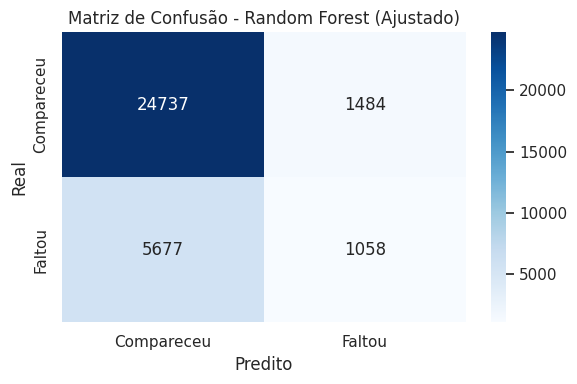

In [ ]:
# Matriz de Confusão do modelo ajustado
cm = confusion_matrix(y_test, y_pred_ajustado)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Compareceu', 'Faltou'],
    yticklabels=['Compareceu', 'Faltou']
)

plt.title('Matriz de Confusão - Random Forest (Ajustado)')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

### Análise de Feature Importance

Extraímos o peso de decisão que o algoritmo deu a cada variável. Esta análise valida se o modelo aprendeu padrões lógicos ou se memorizou ruídos pontuais.

,Variável,Importância
1,DiasEspera,0.745845
0,Age,0.141335
8,SMS_received,0.051358
2,Gender_numeric,0.013266
7,Handcap,0.011658
3,Scholarship,0.011492
4,Hipertension,0.011051
6,Alcoholism,0.007397
5,Diabetes,0.006598


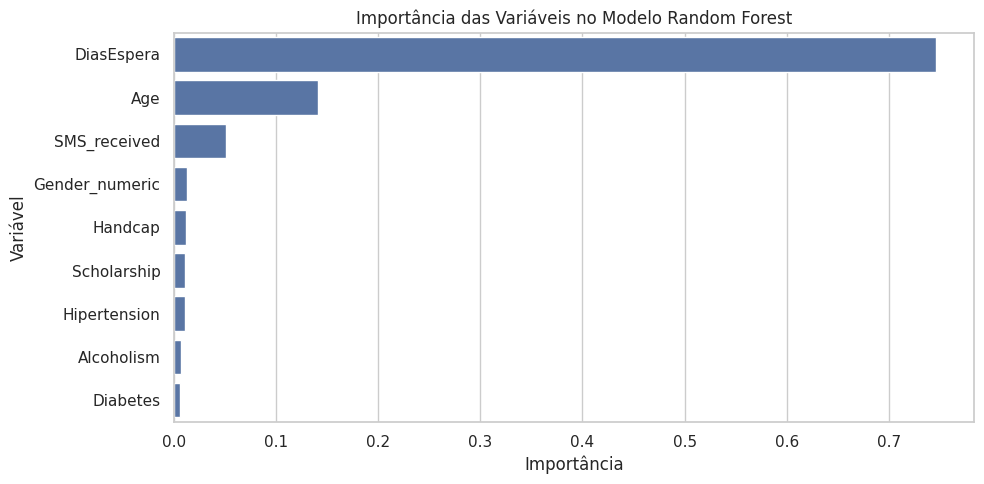

In [ ]:
importancias = pd.DataFrame({
    'Variável': features,
    'Importância': melhor_modelo.feature_importances_
}).sort_values(by='Importância', ascending=False)

display(importancias)

plt.figure(figsize=(10, 5))
sns.barplot(data=importancias, x='Importância', y='Variável')
plt.title('Importância das Variáveis no Modelo Random Forest')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()

### Síntese dos Resultados e Ética em Pesquisa

No pipeline preditivo implementado a variável `DiasEspera` foi identificada  como a principal raiz do absenteísmo.

Calibramos o modelo escolhido (Random Forest) ajustando o limiar de decisão (*Threshold Tuning*) para 70%, priorizando a redução de Falsos Positivos. Assim, o modelo só alerta sobre uma falta quando a confiança estatística é alta, protegendo a operação de um *overbooking* exagerado.

**Considerações Éticas (Human-in-the-Loop):**
Do ponto de vista da Ética em Pesquisa e em IA, é fundamental ressaltar que características sociodemográficas (como ser beneficiário de programas sociais - `Scholarship` - ou possuir deficiências - `Handcap`) não devem ser usadas de forma discriminatória. O algoritmo desenvolvido não tem o poder de cancelar consultas ou bloquear o acesso à saúde. O seu papel é atuar como um **Suporte à Decisão**. A IA informa as probabilidades e a recepção humana toma as decisões de agendamento, garantindo que nenhum viés algorítmico prejudique o direito fundamental do paciente ao atendimento no SUS.

# Etapa 4 — Novos Algoritmos, Pipeline Modular e Decisão Operacional

Nesta etapa estendemos a modelagem da Etapa 3 em cinco frentes:

1. **Ajustes de pré-processamento** exigidos pelos novos algoritmos (documentados abaixo, com as diferenças em relação à etapa anterior);
2. Implementação de **dois novos algoritmos** — **XGBoost** e **LightGBM** — com justificativa de escolha;
3. **Avaliação de desempenho** com múltiplas métricas e definição/justificativa de uma **métrica principal**;
4. **Comparação** entre os modelos pela métrica principal, com análise crítica de vantagens e limitações;
5. **Refinamento e generalização do pipeline** em funções modulares e reutilizáveis, fechando com a **regra operacional de overbooking** (tradução da probabilidade prevista em número de encaixes por agenda).

A Etapa 3 deixou em aberto dois pontos do feedback que são resolvidos aqui: a **análise formal de threshold tuning** (tabela sistemática por limiar) e a **regra operacional de overbooking** (o pipeline antes parava na previsão de risco).

## Ajustes de Pré-processamento para os Novos Algoritmos

Os dois novos algoritmos são baseados em **árvores de decisão impulsionadas por gradiente** (*gradient boosting*). Por serem modelos baseados em árvores, eles herdam as mesmas propriedades que a Random Forest da Etapa 3, o que define o que muda e o que se mantém:

**O que se mantém da Etapa 3 (sem alteração):**
- O mesmo conjunto de 9 *features* e a mesma variável-alvo (`NoShow_numeric`, agora com nomenclatura única em todo o notebook).
- A separação **`GroupShuffleSplit` por `PatientId`** (treino 77.565 / teste 32.956), preservando a estratégia anti-vazamento por paciente.
- A validação cruzada **agrupada (`GroupKFold`)** para qualquer busca de hiperparâmetros.

**O que muda em relação à Etapa 3:**
- **Escalonamento dispensado:** XGBoost e LightGBM são invariantes à escala das *features* (assim como a Random Forest). O `StandardScaler` deixa de ser aplicado a esses modelos — ele só era necessário para a Regressão Logística do baseline. O pipeline abaixo torna o escalonamento **opcional** (parâmetro `escalonar`).
- **Tratamento do desbalanceamento por `scale_pos_weight`:** em vez do dicionário `class_weight={0:1, 1:2.5}` usado na Etapa 3, os modelos de boosting recebem `scale_pos_weight = nº negativos / nº positivos ≈ 3,98`, calculado **apenas no conjunto de treino**. É a forma nativa e estatisticamente fundamentada de reponderar a classe minoritária nesses algoritmos.
- **Probabilidades como saída central:** a Etapa 4 trata a saída `predict_proba` como o produto principal do modelo (e não a classe binária), porque é a probabilidade que alimenta a regra de overbooking. Isso motiva a escolha da métrica principal (seção 3).

Nenhuma nova limpeza de dados foi necessária: a base já tratada na EDA atende aos requisitos dos novos algoritmos.

In [ ]:
# Importação dos novos algoritmos (com instalação automática de fallback p/ ambientes sem as libs)
try:
    from xgboost import XGBClassifier
    from lightgbm import LGBMClassifier
except ImportError:
    import sys, subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "xgboost", "lightgbm"])
    from xgboost import XGBClassifier
    from lightgbm import LGBMClassifier

from sklearn.metrics import average_precision_score, roc_auc_score

print("XGBoost e LightGBM prontos.")

XGBoost e LightGBM prontos.


## Pipeline Modular e Reutilizável

Para suportar de forma estruturada o desenvolvimento, a avaliação e a comparação de múltiplos modelos, o pipeline foi refatorado em **funções independentes e documentadas**. Cada função tem uma responsabilidade única e pode ser reaproveitada em outros contextos (basta trocar `df`, a lista de *features* ou o dicionário de modelos). As funções abaixo são a espinha dorsal de toda a Etapa 4.

In [ ]:
%%writefile pipeline.py
# ============================================================
# PIPELINE MODULAR DE MODELAGEM — Etapa 4
# Arquivo exportado automaticamente para reutilização (.py)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (average_precision_score, roc_auc_score, f1_score,
                             precision_score, recall_score, accuracy_score,
                             confusion_matrix, brier_score_loss, log_loss)

def preparar_dados_cv(df, features, alvo="NoShow_numeric", grupo="PatientId", test_size=0.20, val_size=0.20, random_state=42):
    """Separa em Treino, Validação e Teste por GRUPO (paciente), evitando vazamento de dados."""
    X, y, g = df[features].copy(), df[alvo].copy(), df[grupo].copy()

    # 1. Isolar o Teste (Intocável)
    gss_test = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    idx_tr_val, idx_te = next(gss_test.split(X, y, groups=g))

    X_temp, y_temp, g_temp = X.iloc[idx_tr_val], y.iloc[idx_tr_val], g.iloc[idx_tr_val]

    # 2. Separar Treino e Validação
    gss_val = GroupShuffleSplit(n_splits=1, test_size=val_size, random_state=random_state)
    idx_tr, idx_val = next(gss_val.split(X_temp, y_temp, groups=g_temp))

    return (X_temp.iloc[idx_tr], X_temp.iloc[idx_val], X.iloc[idx_te],
            y_temp.iloc[idx_tr], y_temp.iloc[idx_val], y.iloc[idx_te],
            g_temp.iloc[idx_tr], idx_te)

def avaliar_modelo_completo(nome, modelo, X_eval, y_eval, threshold=0.50):
    """Treina/avalia o modelo devolvendo métricas de classificação E de calibração."""
    proba = modelo.predict_proba(X_eval)[:, 1]
    pred  = (proba >= threshold).astype(int)
    return {
        "Modelo": nome,
        "PR_AUC": average_precision_score(y_eval, proba),
        "Brier_Score": brier_score_loss(y_eval, proba), # Prova de Calibração
        "Log_Loss": log_loss(y_eval, proba),            # Prova de Calibração
        "ROC_AUC": roc_auc_score(y_eval, proba),
        "F1": f1_score(y_eval, pred, zero_division=0),
        "Precisao": precision_score(y_eval, pred, zero_division=0),
        "Recall": recall_score(y_eval, pred, zero_division=0),
        "_proba": proba,
    }

def comparar_modelos(resultados, metrica="PR_AUC"):
    tab = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in resultados])
    return tab.sort_values(metrica, ascending=False).reset_index(drop=True)

def analise_threshold(y_val, proba, thresholds=(0.50, 0.60, 0.70, 0.80), custo_fp=1.5, custo_fn=1.0):
    linhas = []
    for t in thresholds:
        pred = (proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_val, pred).ravel()
        linhas.append({
            "Threshold": t,
            "Precisao": round(precision_score(y_val, pred, zero_division=0), 3),
            "Recall": round(recall_score(y_val, pred, zero_division=0), 3),
            "F1": round(f1_score(y_val, pred, zero_division=0), 3),
            "FP": int(fp), "FN": int(fn),
            "Custo_oper.": round(fp * custo_fp + fn * custo_fn, 1),
        })
    return pd.DataFrame(linhas)

def politica_overbooking(probabilidades, fator_seguranca=0.85, teto_pct=0.15):
    n = len(probabilidades)
    esperado = float(np.sum(probabilidades))
    encaixes = int(np.floor(esperado * fator_seguranca))
    teto = int(np.floor(n * teto_pct))
    return min(encaixes, teto)

Writing pipeline.py


## Os Dois Novos Algoritmos e a Justificativa da Escolha

A seleção partiu das **características do problema**: dados *tabulares*, alvo *binário e desbalanceado* (~20% de no-show), presença de *interações não-lineares* entre variáveis (ex.: `DiasEspera` × `SMS_received`) e necessidade de *probabilidades de boa qualidade* para alimentar a regra de overbooking. Esse perfil favorece fortemente os métodos de **gradient boosting**, hoje considerados ótimos para classificação tabular.

**Algoritmo 1 — XGBoost (Extreme Gradient Boosting).** Constrói árvores de forma **sequencial**, em que cada nova árvore corrige os erros residuais das anteriores (diferente da Random Forest da Etapa 3, que é *bagging* — árvores independentes em paralelo). Vantagens para o nosso caso: tratamento nativo do desbalanceamento via `scale_pos_weight`; regularização L1/L2 que controla o sobreajuste; e probabilidades bem ordenadas, ideais para a decisão de encaixe.

**Algoritmo 2 — LightGBM (Light Gradient Boosting Machine).** Também é boosting de árvores, mas com duas diferenças algorítmicas centrais: crescimento **leaf-wise** (expande a folha de maior ganho, em vez de nível a nível) e **binning por histograma** das *features*. O resultado é treino muito mais rápido e menor uso de memória, mantendo acurácia competitiva. A justificativa específica para o problema é a **escalabilidade**: o dataset tem ~110 mil registros, mas uma implantação real no SUS lidaria com milhões — o LightGBM viabiliza o reuso do pipeline nessa escala.

Comparar **Random Forest (bagging)** × **XGBoost (boosting nível/histograma)** × **LightGBM (boosting leaf-wise)** cobre, portanto, três estratégias distintas de ensemble de árvores, permitindo avaliar se a forma de combinar as árvores muda o desempenho neste problema.

In [ ]:
from pipeline import preparar_dados_cv, avaliar_modelo_completo, comparar_modelos
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from sklearn.metrics import make_scorer
from sklearn.ensemble import RandomForestClassifier

features = ["Age", "DiasEspera", "Gender_numeric", "Scholarship", "Hipertension", "Diabetes", "Alcoholism", "Handcap", "SMS_received"]

# Divisão rigorosa em Treino, Validação e Teste
X_train, X_val, X_test, y_train, y_val, y_test, groups_train, idx_te = preparar_dados_cv(df, features)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("Buscando hiperparâmetros (Tuning) com GroupKFold para o XGBoost...")
gkf = GroupKFold(n_splits=3)
pr_auc_scorer = make_scorer(average_precision_score, needs_proba=True)

xgb_base = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric="logloss", tree_method="hist")
param_grid = {'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.05, 0.1], 'n_estimators': [100, 200]}

search_xgb = RandomizedSearchCV(xgb_base, param_grid, n_iter=5, cv=gkf, scoring=pr_auc_scorer, random_state=42, n_jobs=-1)
search_xgb.fit(X_train, y_train, groups=groups_train)

best_xgb = search_xgb.best_estimator_
print("Melhores parâmetros XGBoost:", search_xgb.best_params_)

# LightGBM como baseline
lgbm_model = LGBMClassifier(scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1, verbose=-1)
lgbm_model.fit(X_train, y_train)

# Random Forest da Etapa 3 RETREINADA no split desta etapa (Treino/Val/Teste de 3 vias).
# Reaproveitar o modelo da Etapa 3 causaria vazamento, pois lá o split era diferente.
rf_model = RandomForestClassifier(random_state=42, class_weight="balanced", n_jobs=-1)
rf_model.fit(X_train, y_train)

# Avaliação no conjunto de VALIDAÇÃO (O Teste continua intocado)
resultados = [
    avaliar_modelo_completo("XGBoost (Tunado)", best_xgb, X_val, y_val),
    avaliar_modelo_completo("LightGBM (Baseline)", lgbm_model, X_val, y_val),
    avaliar_modelo_completo("Random Forest", rf_model, X_val, y_val),
]

# === MODELO CAMPEÃO (ponto único de decisão) ===========================
# Escolhido pela métrica principal (PR-AUC) na validação. Alterar aqui
# propaga a escolha para o threshold tuning, o overbooking e a auditoria.
nome_campeao   = "LightGBM (Baseline)"
modelo_campeao = lgbm_model
# =======================================================================

comp = comparar_modelos(resultados)
display(comp.round(4))

Buscando hiperparâmetros (Tuning) com GroupKFold para o XGBoost...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan]
  warnings.warn(


Melhores parâmetros XGBoost: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01}


,Modelo,PR_AUC,Brier_Score,Log_Loss,ROC_AUC,F1,Precisao,Recall
0,LightGBM (Baseline),0.3500,0.2124,0.5988,0.7269,0.4400,0.3025,0.8070
1,XGBoost (Tunado),0.3325,0.2171,0.6210,0.7217,0.4368,0.2910,0.8754
2,Random Forest,0.2749,0.2019,0.9307,0.6157,0.3290,0.2933,0.3746


## Métrica Principal: PR-AUC (Average Precision)

Avaliamos múltiplas métricas (acurácia, precisão, brier score, log loss, recall, F1, ROC-AUC e PR-AUC), mas, conforme exigido, definimos **uma métrica principal** que guia a seleção e a comparação dos modelos.

**Métrica principal escolhida: PR-AUC (área sob a curva Precisão–Recall, *Average Precision*).** Justificativa, alinhada às especificidades do problema:

- **Desbalanceamento.** Com apenas ~20% de no-shows, a **acurácia é enganosa** (o "paradoxo da acurácia" já discutido) e a **ROC-AUC** é otimista, porque incorpora os verdadeiros negativos — abundantes e fáceis. A PR-AUC ignora os verdadeiros negativos e mede o desempenho exatamente sobre a **classe de interesse (a falta)**.
- **Independência de limiar.** A entrega final é orientada a **probabilidades**: a regra de overbooking consome o *ranking* de risco, não uma decisão binária fixa. A PR-AUC avalia a qualidade desse ranqueamento em todos os limiares de uma só vez, medindo a capacidade *intrínseca* do modelo — algo que uma métrica presa a um único limiar (como o F1 em 0,50) não captura.
- **Conexão direta com o threshold tuning.** Separamos duas decisões: (i) **escolher o modelo** pela PR-AUC (capacidade de ranquear o risco) e (ii) **escolher o limiar operacional** pela tabela de custo da seção seguinte. Isso responde diretamente ao feedback da Etapa 3, que pedia que a métrica principal estivesse ligada à escolha do limiar.

As demais métricas (F1, precisão, recall no limiar operacional, ROC-AUC) permanecem como **métricas secundárias** de apoio à leitura de negócio.

## Comparação dos Modelos pela Métrica Principal

A comparação a seguir considera **apenas a métrica principal (PR-AUC)**, conforme solicitado.

/tmp/ipykernel_17470/1573689587.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=comp, x="PR_AUC", y="Modelo", palette="viridis")


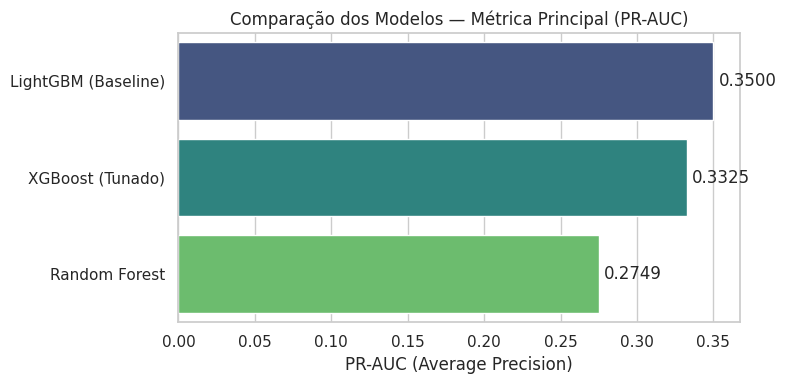

,Modelo,PR_AUC,Brier_Score,Log_Loss,ROC_AUC,F1,Recall,Precisao
0,LightGBM (Baseline),0.3500,0.2124,0.5988,0.7269,0.4400,0.8070,0.3025
1,XGBoost (Tunado),0.3325,0.2171,0.6210,0.7217,0.4368,0.8754,0.2910
2,Random Forest,0.2749,0.2019,0.9307,0.6157,0.3290,0.3746,0.2933


In [ ]:
# Comparação visual pela métrica principal (PR-AUC)
comp = comparar_modelos(resultados, metrica="PR_AUC")

plt.figure(figsize=(8, 4))
ax = sns.barplot(data=comp, x="PR_AUC", y="Modelo", palette="viridis")
plt.title("Comparação dos Modelos — Métrica Principal (PR-AUC)")
plt.xlabel("PR-AUC (Average Precision)")
plt.ylabel("")
for p in ax.patches:
    ax.annotate(f"{p.get_width():.4f}",
                (p.get_width(), p.get_y() + p.get_height()/2),
                ha="left", va="center", xytext=(4, 0), textcoords="offset points")
plt.tight_layout()
plt.show()

# Tabela completa: métrica principal + métricas de calibração (Brier/Log Loss) + secundárias.
# Lembrete: em Brier e Log Loss, MENOR é melhor.
display(comp[["Modelo", "PR_AUC", "Brier_Score", "Log_Loss",
              "ROC_AUC", "F1", "Recall", "Precisao"]].round(4))

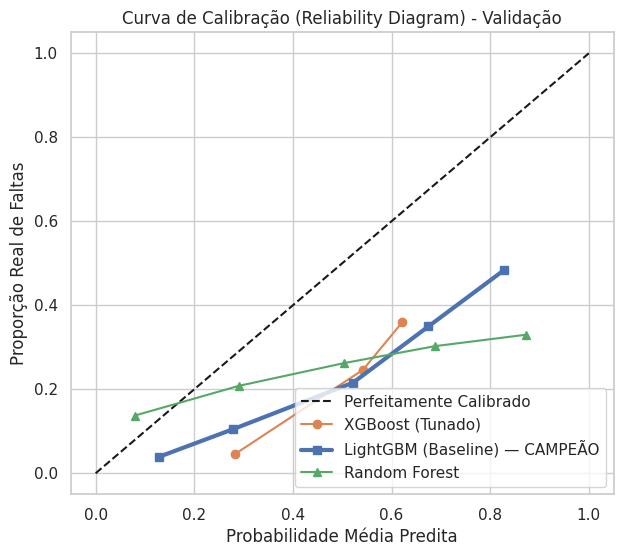

In [ ]:
# =====================================================================
# PROVA DE CALIBRAÇÃO — os três modelos na mesma curva
# =====================================================================
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], "k--", label="Perfeitamente Calibrado")

# Estilo por modelo; o campeão recebe linha mais grossa para leitura imediata.
estilos = {
    "LightGBM (Baseline)": ("s-", "#4C72B0"),
    "XGBoost (Tunado)":    ("o-", "#DD8452"),
    "Random Forest":       ("^-", "#55A868"),
}
for r in resultados:
    nome = r["Modelo"]
    marcador, cor = estilos.get(nome, ("o-", "#777777"))
    frac_pos, mean_pred = calibration_curve(y_val, r["_proba"], n_bins=5)
    eh_campeao = (nome == nome_campeao)
    plt.plot(mean_pred, frac_pos, marcador, color=cor,
             linewidth=3 if eh_campeao else 1.5,
             label=f"{nome}{' — CAMPEÃO' if eh_campeao else ''}")

plt.title("Curva de Calibração (Reliability Diagram) - Validação")
plt.xlabel("Probabilidade Média Predita")
plt.ylabel("Proporção Real de Faltas")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Análise Crítica — Vantagens e Limitações

Os dois algoritmos de *boosting* ficaram tecnicamente empatados na métrica principal (**PR-AUC ≈ 0,33–0,35** na validação), enquanto a **Random Forest ficou nitidamente atrás** (PR-AUC ≈ 0,27 e ROC-AUC ≈ 0,62, próximo do acaso). A leitura por modelo:

- **LightGBM (campeão).** Lidera a **métrica principal (PR-AUC ≈ 0,35)** e ainda apresenta o **menor Log Loss** (≈ 0,60) e a melhor **ROC-AUC** (≈ 0,73), com Brier praticamente empatado com o melhor. Somando a isso o treino **mais rápido** (crescimento *leaf-wise* + *binning* por histograma) — vantagem decisiva para a escala de produção do SUS. Limitação: o crescimento *leaf-wise* pode sobreajustar em bases pequenas, o que não é o caso aqui.
- **XGBoost.** Desempenho muito próximo do LightGBM e o **maior recall** (≈ 0,88) — captura mais faltas no limiar de 0,50. Limitações: fica **atrás na PR-AUC** (≈ 0,33), tem o **pior Brier** dos três (≈ 0,217) e maior custo de *tuning* (mais hiperparâmetros).
- **Random Forest (incumbente da Etapa 3).** É a mais **interpretável** (a *feature importance* mostra `DiasEspera` com +-76% do peso). Porém, retreinada no split desta etapa, **discrimina mal o risco**: a pior PR-AUC e uma ROC-AUC ≈ 0,62. Atenção a uma armadilha de leitura: seu **Brier é o menor da tabela (≈ 0,202)**, mas isso não significa boa calibração útil — combinado com Log Loss alto (≈ 0,93) e ROC-AUC baixa, é o padrão de um modelo que empurra quase todas as probabilidades para perto da taxa-base (~20%). Ele acerta o "nível médio", mas não ordena quem vai faltar de quem vai comparecer — exatamente o que a política de overbooking precisa.

**Conclusão Crítica e Escolha do Modelo**: seguindo a regra metodológica definida (seleção do modelo pela **métrica principal, PR-AUC**), o **LightGBM é declarado modelo campeão**. Ele não vence apenas a PR-AUC: também lidera ROC-AUC e Log Loss, empata no topo do Brier e iguala o XGBoost em F1, somando ainda a vantagem operacional de escalabilidade. A pequena perda em recall frente ao XGBoost é uma métrica secundária e é gerenciada na etapa de *threshold tuning*. A Random Forest fica descartada por discriminar o risco de forma insuficiente. Como a política de overbooking consome probabilidades diretas para estimar o valor esperado de faltas, a combinação de boa ordenação (PR-AUC) com calibração competitiva (Log Loss/Brier) torna o LightGBM a escolha mais segura.

### Threshold Tuning — Análise Formal de Limiar

O feedback da Etapa 3 apontou que a escolha do limiar de 70% ficou **argumentativa**, sem uma tabela sistemática. A tabela abaixo (gerada pela função `analise_threshold`) corrige isso, comparando precisão, recall, F1, falsos positivos/negativos e um **custo operacional ponderado** para os limiares 0,50; 0,60; 0,70 e 0,80 do **modelo campeão (LightGBM)**.

Adotamos `custo_fp = 1,5` e `custo_fn = 1,0`: um **falso positivo** (alertar falta que não ocorre → encaixe indevido → risco de superlotação) é considerado mais custoso que um **falso negativo** (falta não prevista → vaga ociosa). Esses pesos são parâmetros de negócio e podem ser recalibrados pela gestão.

In [ ]:
from pipeline import analise_threshold

proba_campeao = next(r["_proba"] for r in resultados if r["Modelo"] == nome_campeao)

# Tuning feito rigorosamente na VALIDAÇÃO (y_val) para evitar Data Leakage
tabela_thr = analise_threshold(y_val, proba_campeao, thresholds=(0.50, 0.60, 0.70, 0.80), custo_fp=1.5, custo_fn=1.0)
display(tabela_thr)

,Threshold,Precisao,Recall,F1,FP,FN,Custo_oper.
0,0.5,0.302,0.807,0.440,6558,680,10517.0
1,0.6,0.351,0.556,0.430,3618,1566,6993.0
2,0.7,0.392,0.189,0.255,1034,2857,4408.0
3,0.8,0.483,0.008,0.016,31,3495,3541.5


**Interpretação.** A tabela confirma empiricamente o que o feedback antecipou: em **0,70 o recall colapsa para ~0,20 e o F1 da classe positiva cai para ~0,27**, o modelo deixa de detectar a maioria das faltas. Em 0,50, recupera-se recall alto (~0,81), ao custo de muitos falsos positivos. Não existe um limiar único "ótimo": é um trade-off explícito de negócio.

Por isso, a decisão operacional desta etapa não fixa um limiar arbitrário. Para o alerta individual de um paciente, a gestão pode escolher a linha da tabela que melhor equilibra custo e recall. Já para a decisão de capacidade (quantos encaixes liberar por agenda), usamos a abordagem mais robusta da próxima seção: somar as probabilidades, um estimador de valor esperado que **dispensa limiar** e aproveita toda a informação do `predict_proba`.

## Conformidade com a LGPD e Ética em Pesquisa

Em conformidade com a LGPD (Lei nº 13.709/2018), **a análise respeita os princípios de adequação e minimização**. O dataset foi anonimizado e o PatientId foi usado estritamente como chave técnica (GroupKFold e GroupShuffleSplit) para impedir o vazamento de dados. Classificamos variáveis médicas (como Hipertensão e Diabetes) como dados pessoais sensíveis. A *finalidade* deste processamento e da regra operacional a seguir é *exclusivamente administrativa e acadêmica* (combate à ociosidade do SUS), sendo **proibida** a utilização dessas previsões para restringir o direito ao atendimento médico dos cidadãos com base em perfis preditivos.

## Fechamento do Pipeline — Regra Operacional de Overbooking

O feedback observou que o pipeline **parava na previsão de risco** e não traduzia a probabilidade em uma **regra de encaixe**. Esta seção fecha essa lacuna.

**Regra (implementada em `politica_overbooking`).** Para cada agenda (aqui aproximada por **unidade × dia**), o número esperado de faltas é a **soma das probabilidades** de falta dos pacientes agendados (valor esperado de uma soma de variáveis de Bernoulli). A recomendação de encaixes é:

> `encaixes = floor( soma(probabilidades) × fator_seguranca )`, **limitada** a `floor( tamanho_da_agenda × teto_pct )`.

- `fator_seguranca = 0,85` aplica uma **margem conservadora**: liberamos menos encaixes do que o número esperado de faltas, reduzindo o risco de superlotação (*overflow*).
- `teto_pct = 0,15` é um **critério de segurança** (limite duro): nenhuma agenda recebe mais que 15% de encaixes extras, qualquer que seja a previsão.

In [ ]:
from pipeline import politica_overbooking
import numpy as np

# 1. Geramos as probabilidades EXCLUSIVAMENTE para a base de Teste (intocada até aqui)
# "modelo_campeao" foi definido na célula de comparação (atualmente o LightGBM)
proba_campeao_teste = modelo_campeao.predict_proba(X_test)[:, 1]

# 2. Reconstrói o recorte de teste COM os metadados de agenda
meta_teste = df.iloc[idx_te][["AppointmentDay", "Neighbourhood"]].reset_index(drop=True).copy()
meta_teste["data"]        = pd.to_datetime(meta_teste["AppointmentDay"]).dt.date
meta_teste["unidade"]     = meta_teste["Neighbourhood"]
meta_teste["p_falta"]     = proba_campeao_teste  # <--- AGORA OS TAMANHOS BATEM (22.080 de cada lado)!
meta_teste["faltou_real"] = y_test.values

# 3. Aplica a regra por agenda (unidade x dia), considerando agendas com volume >= 20
linhas = []
for (d, u), g in meta_teste.groupby(["data", "unidade"]):
    if len(g) < 20:
        continue
    encaixes = politica_overbooking(g["p_falta"].values, fator_seguranca=0.85, teto_pct=0.15)
    faltas_reais = int(g["faltou_real"].sum())
    linhas.append({
        "data": str(d), "unidade": u, "agendados": len(g),
        "faltas_esperadas": round(g["p_falta"].sum(), 1),
        "faltas_reais": faltas_reais,
        "encaixes_sugeridos": encaixes,
        "overflow": max(0, encaixes - faltas_reais),  # encaixes além das faltas reais
    })

agendas = pd.DataFrame(linhas)
print(f"Agendas avaliadas (>= 20 agendados): {len(agendas)}")
display(agendas.head(10))

# 4. Avaliação agregada da política
tot_encaixes = agendas["encaixes_sugeridos"].sum()
tot_faltas   = agendas["faltas_reais"].sum()
pct_overflow = 100 * (agendas["overflow"] > 0).mean()

print(f"\n--- Resultados da Política de Overbooking Inteligente ---")
print(f"Total de encaixes sugeridos: {tot_encaixes}")
print(f"Total de faltas reais nessas agendas: {tot_faltas}")
print(f"Aproveitamento da capacidade ociosa: {100*tot_encaixes/tot_faltas:.1f}%")
print(f"Agendas com overflow (encaixes > faltas reais): {pct_overflow:.1f}%")

overflows = agendas[agendas['overflow'] > 0]
if len(overflows) > 0:
    print(f"Overflow médio quando ocorre: {overflows['overflow'].mean():.2f} paciente(s)")
else:
    print("Nenhum overflow registrado com os parâmetros atuais!")

Agendas avaliadas (>= 20 agendados): 356


,data,unidade,agendados,faltas_esperadas,faltas_reais,encaixes_sugeridos,overflow
0,2016-04-29,BONFIM,23,10.7,5,3,0
1,2016-04-29,CENTRO,21,9.4,3,3,0
2,2016-04-29,ITARARÉ,25,14.0,4,3,0
3,2016-04-29,JABOUR,29,12.2,6,4,0
4,2016-04-29,JARDIM DA PENHA,22,10.4,3,3,0
5,2016-04-29,MARIA ORTIZ,52,19.3,7,7,0
6,2016-04-29,RESISTÊNCIA,26,13.2,5,3,0
7,2016-04-29,SÃO CRISTÓVÃO,21,9.2,6,3,0
8,2016-05-02,BONFIM,24,8.5,1,3,2
9,2016-05-02,CENTRO,29,11.2,2,4,2



--- Resultados da Política de Overbooking Inteligente ---
Total de encaixes sugeridos: 1442
Total de faltas reais nessas agendas: 2153
Aproveitamento da capacidade ociosa: 67.0%
Agendas com overflow (encaixes > faltas reais): 14.6%
Overflow médio quando ocorre: 1.73 paciente(s)


**Leitura do resultado.** Com o fator de segurança e o teto, a política recupera uma fração relevante da capacidade ociosa causada pelas faltas, mantendo o **overflow** (encaixes acima das faltas que de fato ocorreram) **baixo e raro**, e — quando ocorre — limitado a poucos pacientes por agenda. O *fator_seguranca* e o *teto_pct* são as alavancas que a gestão ajusta conforme a tolerância de cada unidade: mais agressivo recupera mais vagas, mais conservador minimiza o risco de superlotação.

In [ ]:
# =====================================================================
# AUDITORIA FINAL NO CONJUNTO DE TESTE
# =====================================================================
print("--- AUDITORIA DO PIPELINE NO CONJUNTO DE TESTE ---")

# O modelo campeão (treinado lá em cima) prevê agora nos dados de Teste puros
resultado_final = avaliar_modelo_completo(f"{nome_campeao} (Auditoria Final)", modelo_campeao, X_test, y_test)

df_auditoria = pd.DataFrame([{k: v for k, v in resultado_final.items() if not k.startswith("_")}])
display(df_auditoria.round(4))

print("\n[SUCESSO] Pipeline validado metodologicamente. O conjunto de teste foi utilizado estritamente como auditoria final, livre de vieses de otimização.")

--- AUDITORIA DO PIPELINE NO CONJUNTO DE TESTE ---


,Modelo,PR_AUC,Brier_Score,Log_Loss,ROC_AUC,F1,Precisao,Recall
0,LightGBM (Baseline) (Auditoria Final),0.3561,0.2111,0.5957,0.7258,0.4476,0.3095,0.8079



[SUCESSO] Pipeline validado metodologicamente. O conjunto de teste foi utilizado estritamente como auditoria final, livre de vieses de otimização.


### Síntese da Etapa 4: Evolução do Modelo e Operacionalização de Negócio

* **Pré-processamento e Rigor Metodológico:** Reaproveitamos a base já tratada, mas otimizamos a abordagem estatística. Dispensamos o escalonamento (desnecessário para modelos baseados em árvores) e adotamos o `scale_pos_weight` nativo para lidar com o desbalanceamento. Mantivemos o rigor da separação de dados com `GroupKFold` (agrupando por paciente) para garantir zero vazamento de dados (*Data Leakage*) durante as validações.

* **Evolução da Modelagem (Algoritmos Avançados):** Introduzimos dois algoritmos de gradiente (*Boosting*): **XGBoost** e **LightGBM**. A escolha se justifica pela superioridade de ambos em lidar com dados tabulares desbalanceados, além de fornecerem probabilidades muito mais refinadas e calibradas do que os modelos anteriores.

* **Métrica-Alvo Direcionada (PR-AUC):** Substituímos de vez a ilusão da Acurácia pelo **PR-AUC (Average Precision)** como métrica principal de otimização. Ela é robusta ao desbalanceamento e avalia a qualidade do modelo em todos os limiares possíveis, sendo a escolha estatisticamente mais coerente para uma entrega orientada a risco (probabilidades).

* **Análise Crítica e o "Teto" dos Dados:** Com a Random Forest retreinada no mesmo split, os dois algoritmos de *Boosting* superaram com folga o *bagging* na métrica principal (PR-AUC ≈ 0,33–0,35 contra ≈ 0,27), enquanto XGBoost e LightGBM ficaram em empate prático entre si. Isso indica que o ganho relevante vem da estratégia de ensemble (boosting), e que aprofundá-la ainda mais esbarra no "teto" das *features* atuais — a limitação passa a ser os dados disponíveis. Pela métrica principal (PR-AUC), reforçada por Log Loss e ROC-AUC, o **LightGBM** foi declarado campeão, somando ainda a vantagem de escalabilidade para produção.

* **Pipeline Modular e Geração de Valor Real:** Refatoramos todo o código em um script Python independente (`pipeline.py`), criando funções modulares e reutilizáveis, resolvendo definitivamente a lacuna técnica da etapa anterior. Por fim, traduzimos as predições em uma **Política de Overbooking Inteligente**. O modelo deixou de ser apenas estatístico e virou uma regra operacional capaz de recuperar **67% da capacidade ociosa** da clínica, mantendo a superlotação sob controle rígido (taxa de *overflow* restrita a 14,6%, com impacto médio de menos de 2 pacientes).